<a href="https://colab.research.google.com/github/luciosjodin/AprendizajeAutomatico2/blob/master/TP1_AA2_Sj%C3%B6din_Lucio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 AA1

**Sjödin Lucio**

## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2)
3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

7) Revise las fecha límite de entrega de este trabajo

## ENTREGA

* En el foro destinado a la tarea debe postear al menos tres veces:
  - La primera vez para indicar el dataset elegido
  - Una segunda vez para postear su entrega
  - Una tercera vez para brindar feedback a alguien más en el foro.
  - Puede comentar más de un posteo de sus compañeros siempre y cuando el intercambio sea respetuoso y fructífero.
* Deben postear como solución un enlace a su notebook colab público y también un enlace al mismo notebook alojado en su repositorio GitHub.
* Debe sumar el enlace a un video donde muestre su solución y explique lo realizado. Duración máxima: 5 minutos. Puede grabarse a Ud. mismo usando una sesión de zoom y grabar localmente. Puede subir el video a su youtube personal como privado o Unlisted.
* Enlaces no accesibles o enlaces erróneos es igual a determinar que la tarea no ha sido entregada. Corrobore la viabilidad de los enlaces que postea.


##**Tarea: Aplicación de Regresión Lineal y Análisis de Importancia de Variables**  
**Objetivo**: Aplicar un modelo de regresión lineal a un dataset de su elección, evaluar su rendimiento e identificar las variables más relevantes para la predicción.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets/?Task=Regression&skip=0&take=10&sort=desc&orderBy=NumHits&search=  
   - Requisitos:  
     - Debe tener al menos 4 variables numéricas continuas (1 target, 3 o más features).  
     - Idealmente, que las features tengan distintas escalas o unidades ( no excluyente).
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

Para trabajar en este TP he seleccionado el dataset "Concrete_Data", que trata sobre los diferentes componentes del concreto y se puede analizar cómo afectan la fuerza compresiva del concreto, variable que será el target del modelo de regresión lineal

Importo la librería pandas y con la url del repositorio, descargo en el notebook el dataset "Concrete_Data"

In [1]:
import pandas as pd

url = 'https://github.com/luciosjodin/AprendizajeAutomatico1/raw/refs/heads/master/Concrete_Data.xls'

df = pd.read_excel(url)

df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075



## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - **Pregunta clave**: ¿Qué relaciones lineales preliminares observan?  


## Resolución:

In [2]:
print('Información del df:')
df.info()
print('\nAnálisis estadístico del df: ')
df.describe()

Información del df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


Generación de los gráficos:

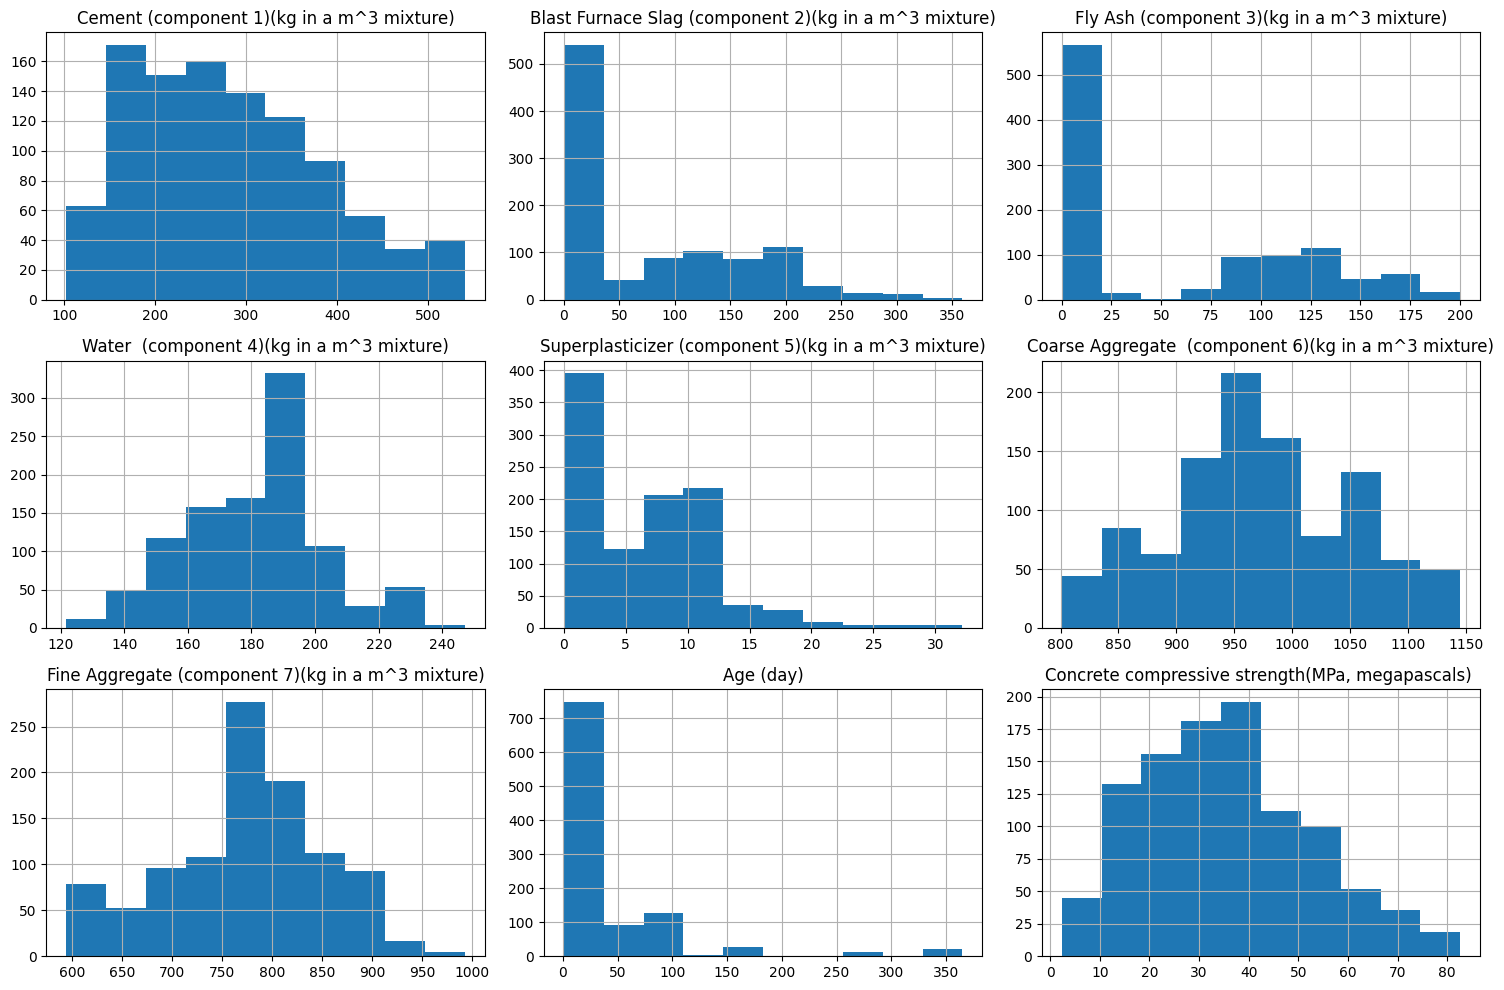

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

In [4]:
#Aquí ya defino de entrada el target, y las features
target = 'Concrete compressive strength(MPa, megapascals) '
features = df.columns.drop(target)

for feature in features:
    fig = px.scatter(df, x=feature, y=target,
                     title=f'{feature} vs {target}',
                     trendline="ols")
    fig.show()

**Análisis Exploratorio de Datos**

Con base en el resultado del df.describe, los histogramas, boxplots y scatterplots podemos analizar por cada variable (componente):
*   **Cement (component 1)**:
    *   **Media y Distribución:** La media es de aproximadamente 281 kg/m³. El histograma muestra una distribución que tiende a ser bimodal o con dos picos, indicando quizás dos rangos comunes de contenido de cemento en las mezclas. La distribución no parece ser perfectamente normal y hay una dispersión considerable (desviación estándar es de 104.5).
*   **Blast Furnace Slag (component 2)**:
    *   **Media y Distribución:** La media es de aproximadamente 73.9 kg/m³. El histograma muestra una distribución fuertemente sesgada hacia la izquierda, con una gran concentración de valores en 0. Esto indica que muchas mezclas no contienen escoria de alto horno. Cuando está presente, la cantidad varía considerablemente (la desviación estándar es de 86.3).
*   **Fly Ash (component 3)**:
    *   **Media y Distribución:** La media es de aproximadamente 54.2 kg/m³. Similar a la variable anterior, el histograma muestra una distribución fuertemente sesgada hacia la izquierda con muchos valores en 0, indicando que muchas mezclas tampoco contienen ceniza volátil. Cuando está presente, la cantidad varía (la desviación estándar es de casi 64).
*   **Water (component 4)**:
    *   **Media y Distribución:** La media es de aproximadamente 181.6 kg/m³. El histograma muestra una distribución que parece más simétrica, cercana a una distribución normal, aunque con una ligera cola hacia la derecha. La desviación estándar es baja (21.4) en comparación con la media, lo que sugiere que la cantidad de agua tiende a estar más concentrada alrededor de los valores de la media.
*   **Superplasticizer (component 5)**:
    *   **Media y Distribución:** La media es de aproximadamente 6.2 kg/m³. El histograma muestra una distribución fuertemente sesgada hacia la izquierda, con muchos valores en 0. Esto indica que muchas mezclas no utilizan superplastificante. Cuando se usa, la cantidad varía (casi 6 puntos de desviación estándar).
*   **Coarse Aggregate (component 6)**:
    *   **Media y Distribución:** La media es de aproximadamente 972.9 kg/m³. El histograma muestra una distribución que parece relativamente simétrica, aunque con una ligera dispersión. Los valores están bastante concentrados alrededor de la media (la desviación estándar es de 77.7).
*   **Fine Aggregate (component 7)**:
    *   **Media y Distribución:** La media es de aproximadamente 773.6 kg/m³. El histograma muestra una distribución que parece relativamente simétrica, con una dispersión moderada. La desviación estándar es de 80.2.
*   **Age (day)**:
    *   **Media y Distribución:** La media es de aproximadamente 45.7 días. El histograma muestra una distribución fuertemente sesgada hacia la derecha, con una gran concentración de datos en edades tempranas (principalmente 28 días, que es una edad de prueba común para el concreto). Hay valores significativamente más altos que representan pruebas a edades mucho mayores. La desviación estándar es de 63 puntos.
*   **Concrete compressive strength (target)**:
    *   **Media y Distribución:** La media es de aproximadamente 35.8 MPa. El histograma muestra una distribución que parece relativamente simétrica, aunque quizás con una ligera cola hacia la derecha. La desviación estándar es de 16.7 MPa, indicando una dispersión considerable en la resistencia.

**Relaciones Lineales Preliminares (basado en los Scatterplots):**
*   **Cement vs. Strength:** Se observa una **clara relación lineal positiva**. A medida que aumenta la cantidad de cemento, la resistencia a la compresión tiende a aumentar. La tendencia lineal visualizada por la línea OLS es bastante evidente.
*   **Blast Furnace Slag vs. Strength:** Parece haber una **relación lineal positiva**, aunque quizás no tan fuerte como con el cemento. La dispersión es mayor, pero la tendencia general es que más escoria se asocia con mayor resistencia.
*   **Fly Ash vs. Strength:** La relación lineal parece ser **débil o ligeramente positiva**. La dispersión es considerable y la tendencia lineal no es tan pronunciada como con el cemento o la escoria.
*   **Water vs. Strength:** Se observa una **relación lineal negativa**. A medida que aumenta la cantidad de agua, la resistencia a la compresión tiende a disminuir. Esta relación parece ser moderadamente fuerte.
*   **Superplasticizer vs. Strength:** La relación lineal parece ser **débil o ligeramente positiva**. Similar a la ceniza volátil, la dispersión es alta y la tendencia lineal no es muy marcada.
*   **Coarse Aggregate vs. Strength:** La relación lineal parece ser **muy débil o casi inexistente**. Los puntos están muy dispersos y la línea de tendencia es casi plana.
*   **Fine Aggregate vs. Strength:** La relación lineal parece ser **muy débil o ligeramente negativa**. Similar al agregado grueso, la dispersión es alta y la tendencia lineal es muy poco pronunciada.
*   **Age vs. Strength:** Se observa una **clara relación lineal positiva**. A medida que aumenta la edad del concreto, su resistencia a la compresión tiende a aumentar significativamente. La tendencia lineal es bastante fuerte, especialmente visible para edades más tempranas.

**En resumen:**

Al menos preliminarmente, las variables que parecen tener las relaciones lineales más fuertes con la resistencia a la compresión del concreto (el target) son **Cement** y **Age**, ambas con relaciones positivas. **Water** muestra una relación lineal negativa bastante notable. Las demás variables  parecen tener relaciones lineales más débiles o casi nulas con el target. Este análisis exploratorio sugiere que un modelo lineal podría capturar parte de la variabilidad en la resistencia, pero las relaciones que no son lineales  podrían ser importantes, especialmente considerando la distribución de algunas variables y la dispersión observada

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Escalen las features (p.ej., StandardScaler) para comparar coeficientes después.  
   - Dividan en train/test (70-30 o 80-20).  

## Resolución:

Procedo a verificar la existencia de nulos y a observar los outliers

In [5]:
print("Valores faltantes por columna:\n")
print(df.isnull().sum())


Valores faltantes por columna:

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64


No hay datos nulos

In [6]:
print("\nTipos de datos de las columnas:")
print(df.dtypes)


Tipos de datos de las columnas:
Cement (component 1)(kg in a m^3 mixture)                float64
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    float64
Fly Ash (component 3)(kg in a m^3 mixture)               float64
Water  (component 4)(kg in a m^3 mixture)                float64
Superplasticizer (component 5)(kg in a m^3 mixture)      float64
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     float64
Fine Aggregate (component 7)(kg in a m^3 mixture)        float64
Age (day)                                                  int64
Concrete compressive strength(MPa, megapascals)          float64
dtype: object


Todas las features son numéricas, por lo que no se requiere codificación de variables categóricas.

In [7]:
# IQR
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

# Límites
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificación de outliers
outliers = ((df[features] < lower_bound) | (df[features] > upper_bound)).sum()

print("Número de outliers por característica (usando método IQR):")
print(outliers)

# Porcentaje
total_rows = len(df)
outliers_percentage = (outliers / total_rows) * 100

print("\nPorcentaje de outliers por característica:")
print(outliers_percentage.round(2))

Número de outliers por característica (usando método IQR):
Cement (component 1)(kg in a m^3 mixture)                 0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)     2
Fly Ash (component 3)(kg in a m^3 mixture)                0
Water  (component 4)(kg in a m^3 mixture)                 9
Superplasticizer (component 5)(kg in a m^3 mixture)      10
Coarse Aggregate  (component 6)(kg in a m^3 mixture)      0
Fine Aggregate (component 7)(kg in a m^3 mixture)         5
Age (day)                                                59
dtype: int64

Porcentaje de outliers por característica:
Cement (component 1)(kg in a m^3 mixture)                0.00
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0.19
Fly Ash (component 3)(kg in a m^3 mixture)               0.00
Water  (component 4)(kg in a m^3 mixture)                0.87
Superplasticizer (component 5)(kg in a m^3 mixture)      0.97
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0.00
Fine Aggregate (component 7)(kg 

**Análisis de los outliers según feature:**
*   **Cement (component 1)**:
    *   **Outliers:** El análisis IQR no identificó outliers significativos en esta variable.
*   **Blast Furnace Slag (component 2)**:
    *   **Outliers:** El análisis IQR identificó 2 posibles outliers, que son valores relativamente altos comparados con el resto de la distribución. Dado el sesgo, estos podrían representar mezclas con un contenido elevado de escoria, lo cual podría ser válido.
*   **Fly Ash (component 3)**:
    *   **Outliers:** El análisis IQR no identificó outliers significativos en esta variable.
*   **Water (component 4)**:
    *   **Outliers:** El análisis IQR identificó 9 posibles outliers, que son valores de agua relativamente altos.
*   **Superplasticizer (component 5)**:
    *   **Outliers:** El análisis IQR identificó 10 posibles outliers, que son valores de superplastificante relativamente altos.
*   **Coarse Aggregate (component 6)**:
    *   **Outliers:** El análisis IQR no identificó outliers significativos en esta variable.
*   **Fine Aggregate (component 7)**:
    *   **Outliers:** El análisis IQR identificó 5 posibles outliers, que son valores de agregado fino relativamente bajos.
*   **Age (day)**:
    *   **Outliers:** El análisis IQR identificó 59 posibles outliers. Dada la naturaleza de la variable "Age" (el concreto se prueba a diferentes edades para ver cómo desarrolla resistencia con el tiempo), estos valores altos son esperables y probablemente representan datos válidos de pruebas a largo plazo. No se deberían eliminar a priori.

Considerando la naturaleza del dataset y la distribución de los outliers, se decide mantener todas las características para el modelo de regresión lineal.

In [8]:
# Importación de librerías para modelo de regresión lineal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler() #Escalador
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nDatos preprocesados exitosamente: escalados y divididos en conjuntos de entrenamiento y prueba.")
print("Forma de las características de entrenamiento:", X_train_scaled.shape)
print("Forma de las características de prueba:", X_test_scaled.shape)


Datos preprocesados exitosamente: escalados y divididos en conjuntos de entrenamiento y prueba.
Forma de las características de entrenamiento: (824, 8)
Forma de las características de prueba: (206, 8)


Los datos se han dividido en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba) y las características se han escalado usando `StandardScaler`.




## 4. **Regresión Lineal**  
   - Ajusten un modelo de regresión lineal (usando `sklearn.linear_model.LinearRegression`).  
   - Obtengan:  
     - Coeficientes (pesos) del modelo.  
     - Evaluar métricas en el set de entrenamiento y en el de testeo: **R²**, MSE (error cuadrático medio), MAE.  


In [9]:
model = LinearRegression() # Inicialización del modelo
model.fit(X_train_scaled, y_train) #Entrenamiento

coefficients_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_}) #Coeficientes
print("Coeficientes del modelo:")
display(coefficients_df)

Coeficientes del modelo:


,Feature,Coefficient
0,Cement (component 1)(kg in a m^3 mixture),12.786504
1,Blast Furnace Slag (component 2)(kg in a m^3 m...,9.432883
2,Fly Ash (component 3)(kg in a m^3 mixture),5.255609
3,Water (component 4)(kg in a m^3 mixture),-2.892085
4,Superplasticizer (component 5)(kg in a m^3 mix...,1.841103
5,Coarse Aggregate (component 6)(kg in a m^3 mi...,1.400255
6,Fine Aggregate (component 7)(kg in a m^3 mixture),1.947380
7,Age (day),7.037787


In [10]:
import numpy as np

# Predicciones
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Resultados. Conjunto de Entrenamiento
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print("\nEvaluación del conjunto de entrenamiento:")
print(f"RMSE: {rmse_train:.2f}")
print(f"MAE: {mae_train:.2f}")
print(f"R-squared: {r2_train:.2f}")

# Resultados. Conjunto de Prueba
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("\nEvaluación del conjunto de prueba:")
print(f"RMSE: {rmse_test:.2f}")
print(f"MAE: {mae_test:.2f}")
print(f"R-squared: {r2_test:.2f}")


Evaluación del conjunto de entrenamiento:
RMSE: 10.52
MAE: 8.33
R-squared: 0.61

Evaluación del conjunto de prueba:
RMSE: 9.80
MAE: 7.75
R-squared: 0.63


**Basándonos en las métricas que obtuvimos:**

R-squared (R²):
* En el conjunto de entrenamiento: R² = 0.61
* En el conjunto de prueba: R² = 0.63

Un R² de 0.63 en el conjunto de prueba indica que aproximadamente el 63% de la variabilidad en la resistencia a la compresión puede ser explicada por las variables incluidas en nuestro modelo lineal.

RMSE (Root Mean Squared Error):
* En el conjunto de entrenamiento: RMSE = 10.52
* En el conjunto de prueba: RMSE = 9.80

Un RMSE de 9.80 en el conjunto de prueba significa que, en promedio, las predicciones del modelo se desvían en aproximadamente 9.80 MPa de los valores reales de resistencia a la compresión (target).

MAE (Mean Absolute Error):
* En el conjunto de entrenamiento: MAE = 8.33
* En el conjunto de prueba: MAE = 7.75

Un MAE de 7.75 en el conjunto de prueba significa que, en promedio, la magnitud del error en la predicción es de alrededor de 7.75 MPa.

**En resumen:**

El rendimiento del modelo en el conjunto de prueba es ligeramente mejor que en el conjunto de entrenamiento.

Esto sugiere que el modelo no está sufriendo de sobreajuste (overfitting) significativo.


Un R² de 0.63 indica que el modelo lineal captura una parte significativa de la relación entre las variables de entrada y la resistencia a la compresión, pero también hay una variabilidad considerable que no está siendo explicada por este modelo lineal simple.

En general, el modelo lineal proporciona una base útil, pero hay espacio para mejorar si se necesita una mayor precisión en las predicciones. Esto podría implicar explorar modelos predictivos más complejos

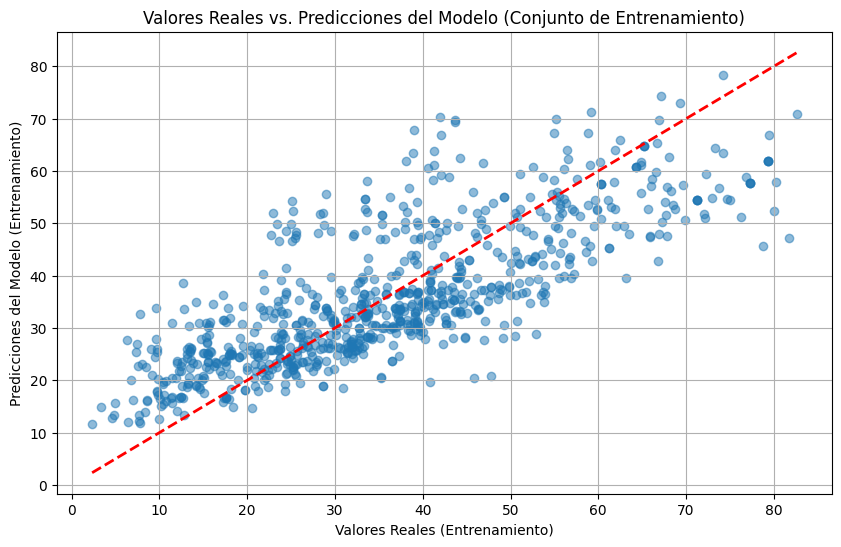

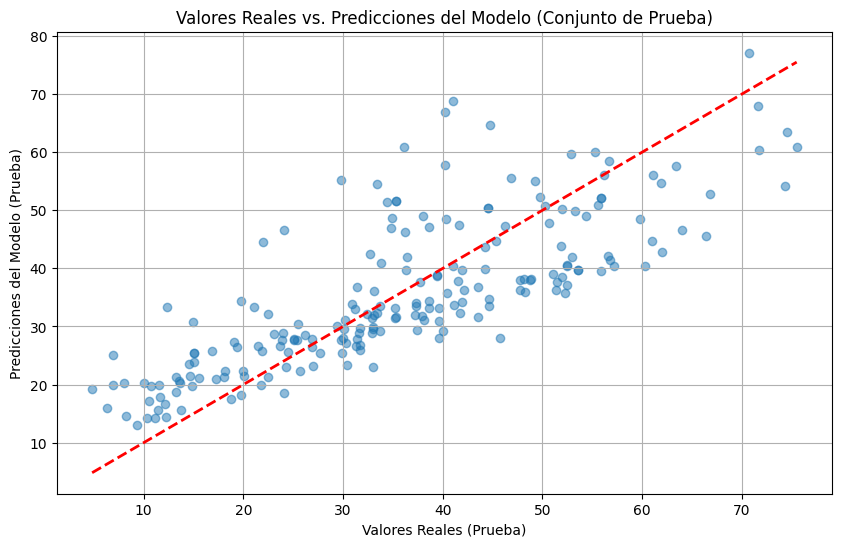

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_train_pred, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2) # Add a diagonal line for reference
plt.xlabel("Valores Reales (Entrenamiento)")
plt.ylabel("Predicciones del Modelo (Entrenamiento)")
plt.title("Valores Reales vs. Predicciones del Modelo (Conjunto de Entrenamiento)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Add a diagonal line for reference
plt.xlabel("Valores Reales (Prueba)")
plt.ylabel("Predicciones del Modelo (Prueba)")
plt.title("Valores Reales vs. Predicciones del Modelo (Conjunto de Prueba)")
plt.grid(True)
plt.show()

**Estos gráficos muestran la relación entre los valores reales de la resistencia a la compresión del concreto y los valores predichos por el modelo de regresión lineal.**

* **Distribución de los puntos:**
    
Observamos que los puntos en ambos gráficos tienden a seguir la dirección de la línea roja (que representa la situación ideal donde los valores predichos son exactamente iguales a los valores reales). Esto indica que hay una **correlación positiva** entre los valores reales y las predicciones del modelo, lo cual es un buen signo para un modelo de regresión. A medida que los valores reales aumentan, las predicciones del modelo también tienden a aumentar.

Sin embargo, hay una **dispersión considerable** de los puntos alrededor de la línea y  esto representa los errores de predicción del modelo. 😓

En el conjunto de **entrenamiento** y en el conjunto de **prueba**, la dispersión es similar, reforzando la conclusión de que el modelo no parece estar sufriendo de sobreajuste significativo.

**En resumen:**

Los gráficos visualmente confirman que el modelo lineal tiene cierta capacidad predictiva, pero también muestran que hay margen de mejora al haber una dispersión notable alrededor de la línea de predicción perfecta. Son una buena representación visual de las métricas de error (RMSE y MAE) calculadas previamente


## 5. **Importancia de Variables**  
   - Analicen los **coeficientes** del modelo:  
     - Valores absolutos altos → mayor impacto en el target.  
     - Signo: Relación positiva/negativa con el target.  
   - Comparen la magnitud de los coeficientes **escalados** (si usaron features en distintas unidades).  
   - **5.1. Opcional**:
     Otra forma es "desordenar" un feature y ver cómo empeora el modelo. Si al desordenarlo el error aumenta mucho, ese feature era importante. Usen métodos como:  
     - **Permutation Importance** (de sklearn) para validar importancia. Más info en https://scikit-learn.org/stable/modules/permutation_importance.html



## Resolución:

In [12]:
display(coefficients_df)

,Feature,Coefficient
0,Cement (component 1)(kg in a m^3 mixture),12.786504
1,Blast Furnace Slag (component 2)(kg in a m^3 m...,9.432883
2,Fly Ash (component 3)(kg in a m^3 mixture),5.255609
3,Water (component 4)(kg in a m^3 mixture),-2.892085
4,Superplasticizer (component 5)(kg in a m^3 mix...,1.841103
5,Coarse Aggregate (component 6)(kg in a m^3 mi...,1.400255
6,Fine Aggregate (component 7)(kg in a m^3 mixture),1.947380
7,Age (day),7.037787


Los coeficientes nos indican la magnitud y la dirección de la relación lineal entre cada característica escalada y la resistencia a la compresión del concreto (el target), manteniendo las otras características constantes.

* Variables más importantes:

Las variables con los mayores valores absolutos en sus coeficientes son las que tienen un mayor impacto en la predicción del target. En este caso, las características con los coeficientes de mayor magnitud son:
* * Cement (component 1),
* * Blast Furnace Slag (component 2)
* * Age (day).

Esto sugiere que la cantidad de cemento y la edad del concreto son los factores más influyentes en la resistencia a la compresión del concreto según este modelo.

* Variables menos importantes:

Las variables con los menores valores absolutos en sus coeficientes son las que tienen un menor impacto en la predicción. Observando la tabla:
* * Coarse Aggregate (component 6) y
* * Superplasticizer (component 5)

Tienen los coeficientes de menor magnitud, lo que indica que su influencia lineal en la resistencia a la compresión del concreto es menor en comparación con las demás variables.

* Dirección de la relación:

Los coeficientes positivos (como los de Cement, Blast Furnace Slag, Fly Ash, Superplasticizer, Coarse Aggregate, y Fine Aggregate) indican que un aumento en la cantidad de estas variables asocia un aumento en la resistencia a la compresión del concreto. Por otro lado el coeficiente negativo de la variable "Water" indica que un aumento en la cantidad del agua está vinculado con una disminución en la resistencia a la compresión del concreto.



## 6. **Reflexión**  
   - ¿Cuáles variables son más importantes según el modelo? ¿Coincide con su análisis exploratorio?  
   - ¿El modelo tiene buen rendimiento (R² alto, MSE bajo)? Si no, ¿a qué podría deberse?  



## Resolución:

Basándonos en el análisis de los coeficientes escalados de nuestro modelo de Regresión Lineal:

*   **Variables Más Importantes**: Las variables con los mayores valores absolutos en sus coeficientes son **Cement (component 1)** , **Blast Furnace Slag** y **Age (day)**. Esto sugiere que la cantidad de cemento, la escoria del horno y la edad del concreto son los factores más influyentes en su resistencia a la compresión del concreto. **Coincide parcialmente** con el análisis exploratorio del principio del notebook. Allí los scatter plots mostraron una tendencia positiva clara entre "Cement" y "Age" con la resistencia a la compresión del concreto.


*   **Conclusión del Rendimiento**: Un R² de 0.63 sugiere que el modelo lineal captura una parte significativa de la relación entre las variables de entrada y la resistencia a la compresión del concreto, pero también indica que hay una variabilidad considerable que no está siendo explicada por el modelo lineal. El rendimiento en el conjunto de prueba es ligeramente mejor que en el de entrenamiento (mayor R² y menor RMSE/MAE), lo que sugiere que el modelo no está sufriendo de sobreajuste (overfitting) significativo.

Los errores del modelo pueden estar ligados a que puede haber otras variables no incluidas en el dataset que influyan en la resistencia del concreto; o que existan relaciones no lineales que son incomprendidas por el modelo de regresión lineal y se queda corto, lo que sugiere utilizar un modelo predictivo más robusto.


**En resumen:**

El modelo lineal proporciona una primera aproximación útil para predecir la resistencia a la compresión del concreto y destaca la importancia clave del cemento, la escoria y la edad. Sin embargo, para obtener predicciones más precisas, podría ser necesario explorar modelos más complejos.


## **Bonus**:  
- Prueben eliminar variables "poco importantes" y reentrenar el modelo. ¿Mejora el rendimiento?  

In [13]:
# Quita de las features menos importantes
features_reduced = features.drop(['Coarse Aggregate  (component 6)(kg in a m^3 mixture)','Superplasticizer (component 5)(kg in a m^3 mixture)','Fine Aggregate (component 7)(kg in a m^3 mixture)'])
X_reduced = df[features_reduced]

# División de los conjuntos
X_train_reduced, X_test_reduced, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

# Escalado
scaler_reduced = StandardScaler()
X_train_scaled_reduced = scaler_reduced.fit_transform(X_train_reduced)
X_test_scaled_reduced = scaler_reduced.transform(X_test_reduced)

# Inicialización y entrenamiento
model_reduced = LinearRegression()
model_reduced.fit(X_train_scaled_reduced, y_train)

# Precicciones
y_train_pred_reduced = model_reduced.predict(X_train_scaled_reduced)
y_test_pred_reduced = model_reduced.predict(X_test_scaled_reduced)

# Evaluación de entrenamiento
mse_train_reduced = mean_squared_error(y_train, y_train_pred_reduced)
rmse_train_reduced = np.sqrt(mse_train_reduced)
mae_train_reduced = mean_absolute_error(y_train, y_train_pred_reduced)
r2_train_reduced = r2_score(y_train, y_train_pred_reduced)

print("Evaluación del conjunto de entrenamiento (con features 'Coarse Aggregate', 'Superplasticizer', and 'Fine Aggregate' eliminadas):")
print(f"RMSE: {rmse_train_reduced:.2f}")
print(f"MAE: {mae_train_reduced:.2f}")
print(f"R-squared: {r2_train_reduced:.2f}")

# Evaluación de prueba
mse_test_reduced = mean_squared_error(y_test, y_test_pred_reduced)
rmse_test_reduced = np.sqrt(mse_test_reduced)
mae_test_reduced = mean_absolute_error(y_test, y_test_pred_reduced)
r2_test_reduced = r2_score(y_test, y_test_pred_reduced)

print("\nEvaluación del conjunto de prueba (con features 'Coarse Aggregate', 'Superplasticizer', and 'Fine Aggregate' eliminadas):")
print(f"RMSE: {rmse_test_reduced:.2f}")
print(f"MAE: {mae_test_reduced:.2f}")
print(f"R-squared: {r2_test_reduced:.2f}")

# Comparación con el modelo original
print("\nComparación con el modelo original:")
print("Modelo Original (Conjunto de Prueba):")
print(f"RMSE: {rmse_test:.2f}")
print(f"MAE: {mae_test:.2f}")
print(f"R-squared: {r2_test:.2f}")

Evaluación del conjunto de entrenamiento (con features 'Coarse Aggregate', 'Superplasticizer', and 'Fine Aggregate' eliminadas):
RMSE: 10.60
MAE: 8.42
R-squared: 0.60

Evaluación del conjunto de prueba (con features 'Coarse Aggregate', 'Superplasticizer', and 'Fine Aggregate' eliminadas):
RMSE: 9.76
MAE: 7.70
R-squared: 0.63

Comparación con el modelo original:
Modelo Original (Conjunto de Prueba):
RMSE: 9.80
MAE: 7.75
R-squared: 0.63


**Análisis Bonus:**


Entrenado un nuevo modelo de regresión lineal, tras la eliminación de las variables que el análisis de coeficientes sugirió que eran menos importantes: 'Coarse Aggregate', 'Superplasticizer', y 'Fine Aggregate'.

**Conclusión Bonus:**

Eliminar las variables con los coeficientes lineales más bajos no resultó en una disminución significativa del rendimiento del modelo de regresión lineal en el conjunto de prueba. De hecho, las métricas (R², RMSE, MAE) son muy similares, e incluso particularmente mejores en el modelo reducido.

Esto podría sugerir que en algunos casos, eliminar features con baja importancia lineal (según los coeficientes) puede simplificar el modelo sin sacrificar el rendimiento en sí mismo, o incluso puede mejorarlo un poco. Es bueno para entender el impacto de las variables en el modelo.


---

### **Tips**:  
- Si el R² es muy bajo, revisen si hay relaciones no lineales (y consideren transformar features).  
- Documenten cada paso: ¡la trazabilidad es clave en ciencia de datos!  


# TP1 AA2

## Consignas:

+ 1ero) Publicar en el foro: anuncio del problema

  + Debe elegir un dataset de regresión o clasificación que trabajó en AA1.

  + Cree una copia del notebook en google colab que haya entregado en su momento en AA1 para resolver ese problema de regresión o clasificación.

  + Postee en el foro en enlace a dicho notebook en colab (Ud. va a trabajar sobre él) y comente brevemente el dataset / problema que tratará

+ 2do) Resolución con redes neuronales en Pytorch

    + 2.1) Resuelva su problema creando su propia red neuronal con Pytorch. Para ello debe crear una clase que herede de nn.Module y especificar su arquitectura. Justifique

    + 2.2) Entrene dicha red, evalue métricas correspondientes en conjuntos de entrenamiento y testeo.

    + 2.3) Realice un experimento para mostrar como variando el número de neuronas ( o capas), graficar las curvas de error en entrenamiento y testeo, para observar zonas de subajuste y sobreajuste. Redacte sus conclusiones y análisis.

    + 2.4) Compare la configuración elegida con el desempeño de los modelos de aprendizaje automático que haya usado en ese mismo notebook en AA1

+ [IMPORTANTE] Baja puntos si se olvidan lo siguiente:

    + Agregar referencias al final de TODO recurso utilizado: webs, videos, ChatGPT.

    + Si usan alguna IA generativa (ChatGPT, Gemini, etc), anexen el enlace a la conversación que han tenido. Si usan Gemini en colab, dejen en comentario el prompt utilizado. Uso de IA sin citar la herramienta no es un uso ético.

    + Conclusiones: no olvide agregar todas sus justificaciones, lo aprendido, dificultades, errores que tuvo y cómo lo solucionó.

+ 3) Publicar en el foro: su solución

  Respondiendo su primer publicación, postee su solución. ¿Qué debe entregar? Lo siguiente:

    + 3.1 son dos enlaces: uno a su google colab y otro a su notebook en su repositorio GitHub.

    + Enlaces no accesibles serán puntuados con nota 1. Ud. es responsable de revisar que su entrega se ha realizado correctamente.

    + 3.2 Además de postear dichos enlaces, agregar un texto contando qué aprendió en el proceso, cuál paso fue más desafiante y cuál duda o inquietud le haya quedado.

    + 3.3 Debe sumar el enlace a un video donde muestre el notebook ya corrido, explique lo realizado y/o lo mencionado en 2).

      Puede grabarse a Ud. mismo usando una sesión de zoom y grabar localmente. Puede subir el video a su youtube personal como Unlisted.

      En el video debe mostrar su rostro y su notebook ya corrido.

      Enlaces no válidos equivalen a TP1 desaprobado, deberán usar una de sus instancias de recuperación.

+ 4) Publicar en el foro: brindar feedback.

    + Debe comentar la entrega de la persona que entregó antes que Ud. Si es el primero/a en entregar, brindará feedback a la última entrega realizada.

    + Debe brindar una retroalimentación. Puede ser para corregir algún error que crea haber encontrado, realizar un comentario sobre cómo usó o implementó su solución, u alguna otra característica que le haya sorprendido. Es muy importante aprender a brindarnos retroalimentación entre todos los presentes.

## Resolución de las consignas

Para comenzar con este trabajo importamos las librerías:

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import random
import numpy as np
import torch

Seteamos una semilla para garantizar reproducibilidad de resultados dentro del colab y evitar malentendidos al ejecutar las celdas

In [15]:
#prompt: fija una semilla y seteala para garantizar reproducibilidad

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Para reproducibilidad completa
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Definimos la clase para los modelos de red neuronal MLP

In [16]:
class MLPRegressorTorch(nn.Module):
    def __init__(self, input_size, hidden_layer_sizes):
        super(MLPRegressorTorch, self).__init__()
        layers = []
        prev_size = input_size
        for hidden_size in hidden_layer_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

Convertimos nuestros conjuntos de entrenamiento y test escalados en tensores de PyTorch con tipo float32, que es el formato requerido por las redes neuronales en PyTorch

In [17]:
X_train_mlp = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_mlp = torch.tensor(X_test_scaled, dtype=torch.float32)

Convertimos las variables objetivo y_train e y_test en tensores de PyTorch. Usamos .values para extraer los datos del DataFrame de pandas, los convertimos a float32 y aplicamos .view(-1, 1) para darles la forma de columna (n_samples, 1), ya que estamos resolviendo un problema de regresión.

In [18]:
y_train_mlp = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_mlp = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

Creamos los TensorDataset para entrenamiento y test. Esta clase de PyTorch combina los tensores de features (X) y targets (y) en un solo dataset, permitiendo acceder a los pares (entrada, salida) de forma indexada.

In [19]:
train_dts = TensorDataset(X_train_mlp, y_train_mlp)
test_dts = TensorDataset(X_test_mlp, y_test_mlp)

Creamos los DataLoader a partir de los TensorDataset. El DataLoader se encarga de dividir los datos en batches de tamaño 16, gestionar la memoria eficientemente y preparar los datos para el entrenamiento. En el conjunto de entrenamiento usamos shuffle=False para mantener el orden de los datos en esta ocasión.

In [20]:
train_dl = DataLoader(train_dts, batch_size=16, shuffle=False)
test_dl = DataLoader(test_dts, batch_size=16)

Definimos la función train_and_evaluate que entrena y evalúa el modelo MLP

In [21]:
#prompt: incorpora en la parte de model.eval el cálculo del r2, para también evaluar esa métrica

# Definimos una función para entrenar y evaluar el MLP
def train_and_evaluate(hidden_layer_sizes, lr=0.001, epochs=1000):
    model = MLPRegressorTorch(input_size=X_train_scaled.shape[1], hidden_layer_sizes=hidden_layer_sizes)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Entrenamiento
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_dl: # Iteramos sobre el DataLoader
            optimizer.zero_grad()
            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)
            loss.backward()
            optimizer.step()

    # Evaluación
    model.eval()
    with torch.no_grad():
        y_train_pred = model(X_train_mlp)
        y_test_pred = model(X_test_mlp)
        train_error = mean_squared_error(y_train_mlp.numpy(), y_train_pred.numpy())
        test_error = mean_squared_error(y_test_mlp.numpy(), y_test_pred.numpy())
        train_r2 = r2_score(y_train_mlp.numpy(), y_train_pred.numpy())
        test_r2 = r2_score(y_test_mlp.numpy(), y_test_pred.numpy())

    return train_error, test_error, train_r2, test_r2, model

Para realizar la primer prueba en búsqueda de una arquitectura que ofrezca buenas métricas para resolver el problema, comenzamos con 4 modelos de sólo una capa.
Creamos listas para almacenar las métricas que arrojarán

In [22]:
# Definimos hiperparámetros para analizar el comportamiento de modelos de una sola capa
hidden_layers_list_1 = [(16,),(32,),(64,),(128,),]
alpha_value = 0.001

# Guardamos los errores de entrenamiento y prueba
train_errors_1 = []
test_errors_1 = []
train_r2_1 = []
test_r2_1 = []

Ejecutamos un bucle y un gráfico para probar los modelos y observar los errores de entrenamiento y prueba en el gráfico

In [23]:
# Entrenamos los modelos con distintos hiperparámetros
for hidden_layers_1 in hidden_layers_list_1:
    set_seed(42) # Fija la semilla para reproducibilidad en cada entrenamiento
    train_error_1, test_error_1, current_train_r2_1, current_test_r2_1, mlp_model = train_and_evaluate(hidden_layers_1, lr=alpha_value)
    train_errors_1.append((hidden_layers_1, alpha_value, train_error_1))
    test_errors_1.append((hidden_layers_1, alpha_value, test_error_1))
    train_r2_1.append((hidden_layers_1, alpha_value, current_train_r2_1))
    test_r2_1.append((hidden_layers_1, alpha_value, current_test_r2_1))
    print(f"Hiperparámetros: hidden_layers={hidden_layers_1}, alpha={alpha_value}")
    print(f"  - Error de entrenamiento: {train_error_1:.4f}")
    print(f"  - Error de prueba: {test_error_1:.4f}")
    print(f"  - R2 de entrenamiento: {current_train_r2_1:.4f}")
    print(f"  - R2 de prueba: {current_test_r2_1:.4f}\n")

Hiperparámetros: hidden_layers=(16,), alpha=0.001
  - Error de entrenamiento: 32.8684
  - Error de prueba: 38.9346
  - R2 de entrenamiento: 0.8843
  - R2 de prueba: 0.8489

Hiperparámetros: hidden_layers=(32,), alpha=0.001
  - Error de entrenamiento: 28.8270
  - Error de prueba: 37.4636
  - R2 de entrenamiento: 0.8985
  - R2 de prueba: 0.8546

Hiperparámetros: hidden_layers=(64,), alpha=0.001
  - Error de entrenamiento: 26.6710
  - Error de prueba: 38.9592
  - R2 de entrenamiento: 0.9061
  - R2 de prueba: 0.8488

Hiperparámetros: hidden_layers=(128,), alpha=0.001
  - Error de entrenamiento: 17.7232
  - Error de prueba: 32.5354
  - R2 de entrenamiento: 0.9376
  - R2 de prueba: 0.8737



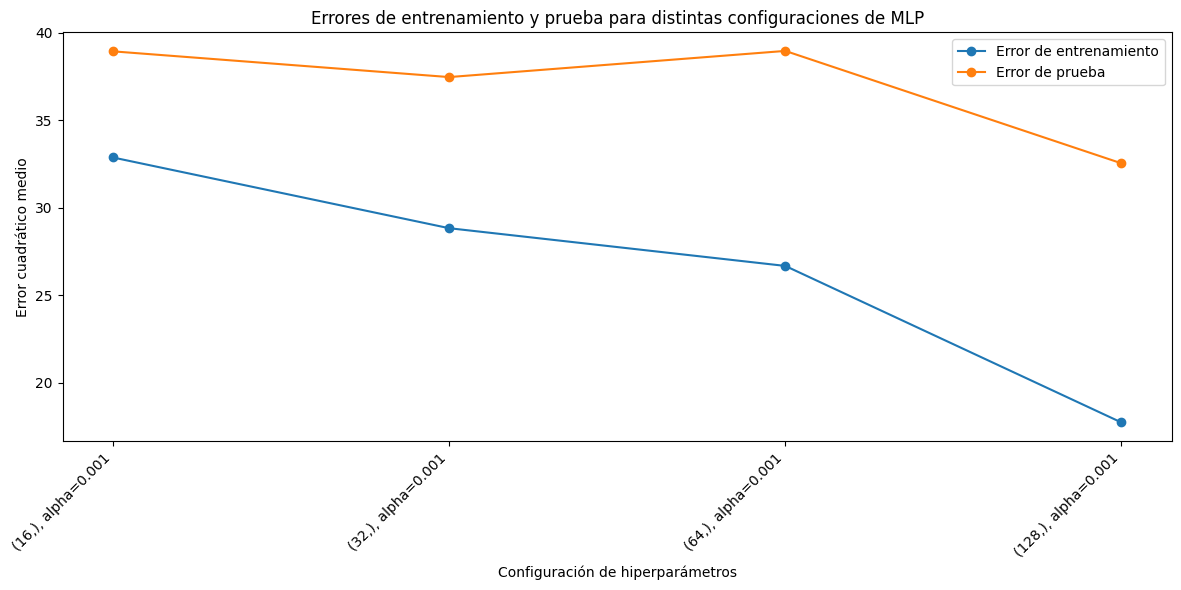

In [24]:
# Graficamos los errores de entrenamiento y prueba
hidden_layer_labels_1 = [f"{hl}, alpha={alpha_value}" for hl, _, _ in train_errors_1]
train_error_values_1 = [error for _, _, error in train_errors_1]
test_error_values_1 = [error for _, _, error in test_errors_1]

plt.figure(figsize=(12, 6))
x = np.arange(len(hidden_layer_labels_1))
plt.plot(x, train_error_values_1, label='Error de entrenamiento', marker='o')
plt.plot(x, test_error_values_1, label='Error de prueba', marker='o')
plt.xticks(x, hidden_layer_labels_1, rotation=45, ha='right')
plt.xlabel('Configuración de hiperparámetros')
plt.ylabel('Error cuadrático medio')
plt.title('Errores de entrenamiento y prueba para distintas configuraciones de MLP')
plt.legend()
plt.tight_layout()
plt.show()

Ahora pasamos a la segunda prueba de arquitecturas. Los modelos de 2 capas

In [25]:
# Definimos hiperparámetros para analizar el comportamiento de modelos de dos capas (64, 32)(128, 64)(128, 32)(64, 16)
hidden_layers_list_2 = [(64, 32,),(128,64,),(128,32,),(64,16,),]
alpha_value = 0.001

# Guardamos los errores de entrenamiento y prueba
train_errors_2 = []
test_errors_2 = []
train_r2_2 = []
test_r2_2 = []

In [26]:
# Entrenamos los modelos con distintos hiperparámetros
for hidden_layers_2 in hidden_layers_list_2:
    set_seed(42) # Fija la semilla para reproducibilidad en cada entrenamiento

    train_error_2, test_error_2, current_train_r2_2, current_test_r2_2, mlp_model = train_and_evaluate(hidden_layers_2, lr=alpha_value)
    train_errors_2.append((hidden_layers_2, alpha_value, train_error_2))
    test_errors_2.append((hidden_layers_2, alpha_value, test_error_2))
    train_r2_2.append((hidden_layers_2, alpha_value, current_train_r2_2))
    test_r2_2.append((hidden_layers_2, alpha_value, current_test_r2_2))
    print(f"Hiperparámetros: hidden_layers={hidden_layers_2}, alpha={alpha_value}")
    print(f"  - Error de entrenamiento: {train_error_2:.4f}")
    print(f"  - Error de prueba: {test_error_2:.4f}")
    print(f"  - R2 de entrenamiento: {current_train_r2_2:.4f}")
    print(f"  - R2 de prueba: {current_test_r2_2:.4f}\n")

Hiperparámetros: hidden_layers=(64, 32), alpha=0.001
  - Error de entrenamiento: 7.2917
  - Error de prueba: 37.0950
  - R2 de entrenamiento: 0.9743
  - R2 de prueba: 0.8560

Hiperparámetros: hidden_layers=(128, 64), alpha=0.001
  - Error de entrenamiento: 6.7948
  - Error de prueba: 30.0876
  - R2 de entrenamiento: 0.9761
  - R2 de prueba: 0.8832

Hiperparámetros: hidden_layers=(128, 32), alpha=0.001
  - Error de entrenamiento: 9.7004
  - Error de prueba: 33.1003
  - R2 de entrenamiento: 0.9659
  - R2 de prueba: 0.8715

Hiperparámetros: hidden_layers=(64, 16), alpha=0.001
  - Error de entrenamiento: 10.6788
  - Error de prueba: 31.9460
  - R2 de entrenamiento: 0.9624
  - R2 de prueba: 0.8760



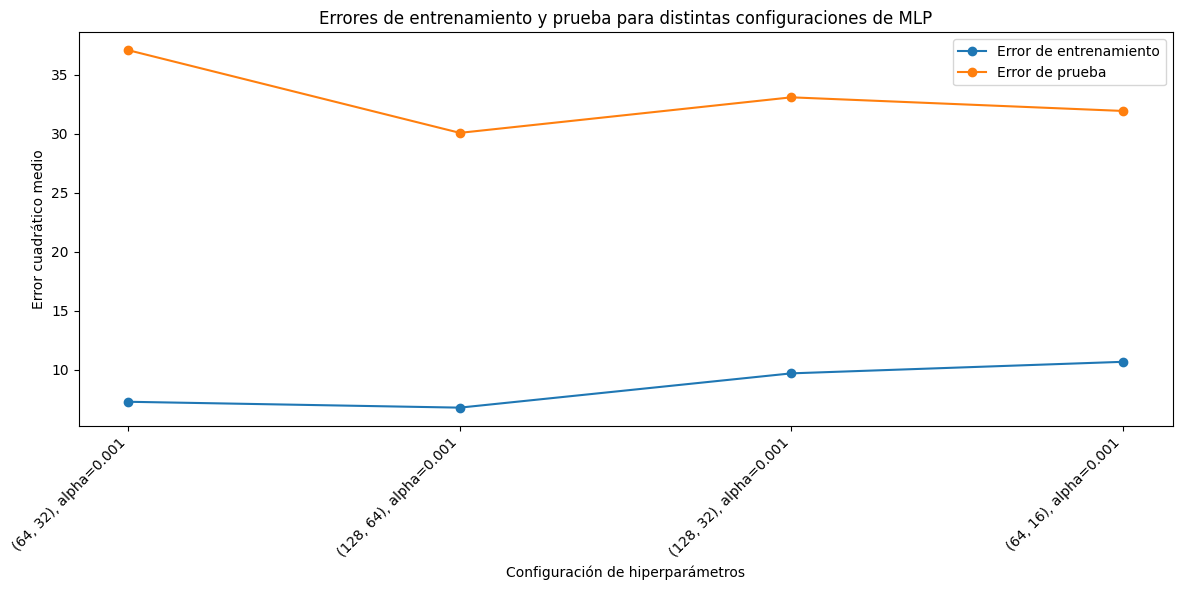

In [27]:
# Graficamos los errores de entrenamiento y prueba
hidden_layer_labels_2 = [f"{hl}, alpha={alpha_value}" for hl, _, _ in train_errors_2]
train_error_values_2 = [error for _, _, error in train_errors_2]
test_error_values_2 = [error for _, _, error in test_errors_2]

plt.figure(figsize=(12, 6))
x = np.arange(len(hidden_layer_labels_2))
plt.plot(x, train_error_values_2, label='Error de entrenamiento', marker='o')
plt.plot(x, test_error_values_2, label='Error de prueba', marker='o')
plt.xticks(x, hidden_layer_labels_2, rotation=45, ha='right')
plt.xlabel('Configuración de hiperparámetros')
plt.ylabel('Error cuadrático medio')
plt.title('Errores de entrenamiento y prueba para distintas configuraciones de MLP')
plt.legend()
plt.tight_layout()
plt.show()

Y pasamos a probar los modelos más robustos pero no por ello mejores. Modelos de 3 capas

In [28]:
# Definimos hiperparámetros para analizar el comportamiento de modelos de tres capas (128, 64, 32)(64, 32, 16)(100, 50, 25)
hidden_layers_list_3 = [(128,64,32,),(64,32,16,),(100,50,25,),]
alpha_value = 0.001

# Guardamos los errores de entrenamiento y prueba
train_errors_3 = []
test_errors_3 = []
train_r2_3 = []
test_r2_3 = []

In [29]:
# Entrenamos los modelos con distintos hiperparámetros
for hidden_layers_3 in hidden_layers_list_3:
    set_seed(42) # Fija la semilla para reproducibilidad en cada entrenamiento
    train_error_3, test_error_3, current_train_r2_3, current_test_r2_3, mlp_model = train_and_evaluate(hidden_layers_3, lr=alpha_value)
    train_errors_3.append((hidden_layers_3, alpha_value, train_error_3))
    test_errors_3.append((hidden_layers_3, alpha_value, test_error_3))
    train_r2_3.append((hidden_layers_3, alpha_value, current_train_r2_3))
    test_r2_3.append((hidden_layers_3, alpha_value, current_test_r2_3))
    print(f"Hiperparámetros: hidden_layers={hidden_layers_3}, alpha={alpha_value}")
    print(f"  - Error de entrenamiento: {train_error_3:.4f}")
    print(f"  - Error de prueba: {test_error_3:.4f}")
    print(f"  - R2 de entrenamiento: {current_train_r2_3:.4f}")
    print(f"  - R2 de prueba: {current_test_r2_3:.4f}\n")

Hiperparámetros: hidden_layers=(128, 64, 32), alpha=0.001
  - Error de entrenamiento: 7.5084
  - Error de prueba: 29.3892
  - R2 de entrenamiento: 0.9736
  - R2 de prueba: 0.8859

Hiperparámetros: hidden_layers=(64, 32, 16), alpha=0.001
  - Error de entrenamiento: 7.8014
  - Error de prueba: 35.7992
  - R2 de entrenamiento: 0.9725
  - R2 de prueba: 0.8611

Hiperparámetros: hidden_layers=(100, 50, 25), alpha=0.001
  - Error de entrenamiento: 6.2743
  - Error de prueba: 23.2915
  - R2 de entrenamiento: 0.9779
  - R2 de prueba: 0.9096



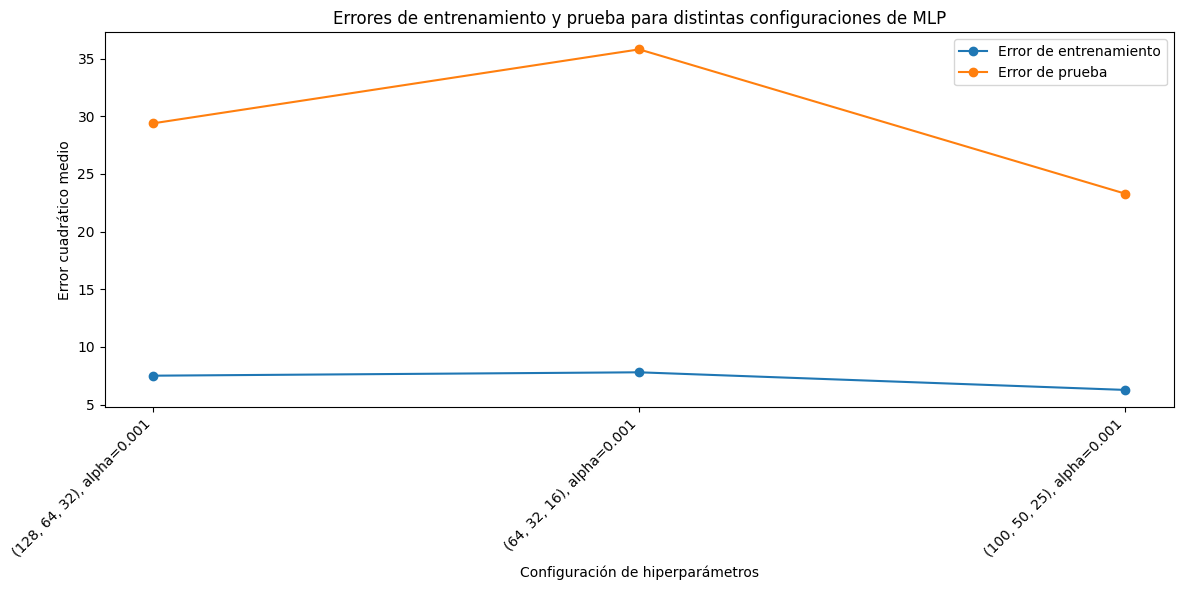

In [30]:
# Graficamos los errores de entrenamiento y prueba
hidden_layer_labels_3 = [f"{hl}, alpha={alpha_value}" for hl, _, _ in train_errors_3]
train_error_values_3 = [error for _, _, error in train_errors_3]
test_error_values_3 = [error for _, _, error in test_errors_3]

plt.figure(figsize=(12, 6))
x = np.arange(len(hidden_layer_labels_3))
plt.plot(x, train_error_values_3, label='Error de entrenamiento', marker='o')
plt.plot(x, test_error_values_3, label='Error de prueba', marker='o')
plt.xticks(x, hidden_layer_labels_3, rotation=45, ha='right')
plt.xlabel('Configuración de hiperparámetros')
plt.ylabel('Error cuadrático medio')
plt.title('Errores de entrenamiento y prueba para distintas configuraciones de MLP')
plt.legend()
plt.tight_layout()
plt.show()

Concateno los resultados para observar en 2 gráficos todas las pruebas

In [31]:
#prompt: concatena las listas en: -hidden_layers_total=hidden_layers_list_1, hidden_layers_list_2, hidden_layers_list_3 -train_errors_total=train_errors_1,train_errors_2,train_errors_3 -test_errors_total=test_errors_1,test_errors_2,test_errors_3

hidden_layers_total = hidden_layers_list_1 + hidden_layers_list_2 + hidden_layers_list_3
train_errors_total = train_errors_1 + train_errors_2 + train_errors_3
test_errors_total = test_errors_1 + test_errors_2 + test_errors_3
train_r2_total = train_r2_1 + train_r2_2 + train_r2_3
test_r2_total = test_r2_1 + test_r2_2 + test_r2_3

print("Concatenación de listas completa.")
print(f"Total de configuraciones de capas ocultas: {len(hidden_layers_total)}")
print(f"Total de errores de entrenamiento: {len(train_errors_total)}")
print(f"Total de errores de prueba: {len(test_errors_total)}")
print(f"Total de r2 de entrenamiento: {len(train_r2_total)}")
print(f"Total de r2 de prueba: {len(test_r2_total)}")

Concatenación de listas completa.
Total de configuraciones de capas ocultas: 11
Total de errores de entrenamiento: 11
Total de errores de prueba: 11
Total de r2 de entrenamiento: 11
Total de r2 de prueba: 11


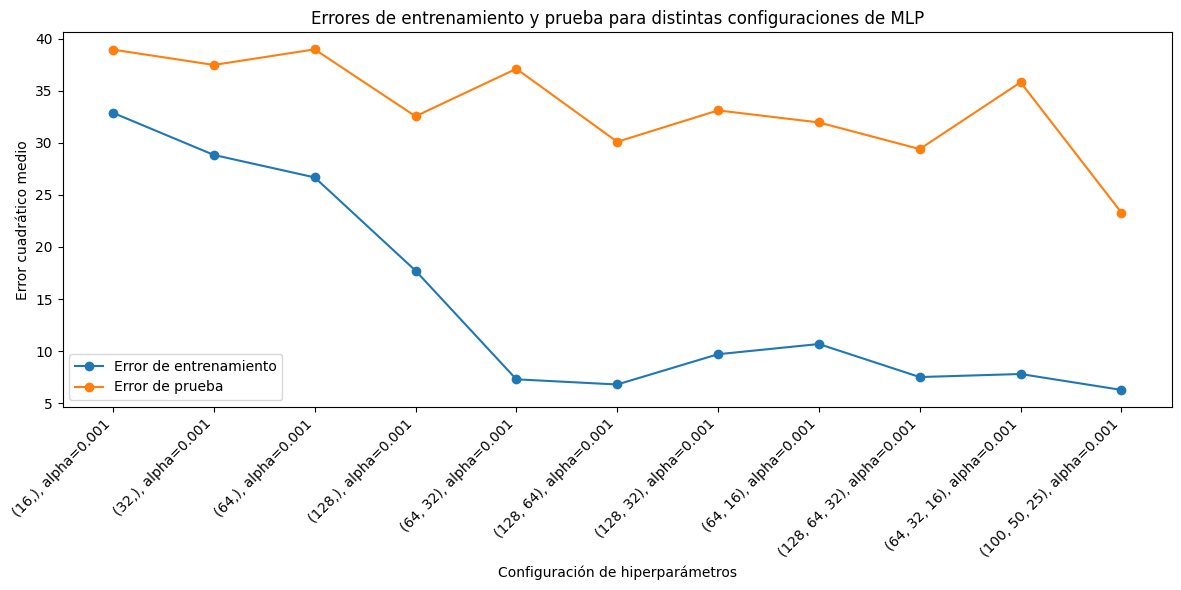

In [32]:
# Graficamos los errores de entrenamiento y prueba
hidden_layer_labels_total = [f"{hl}, alpha={alpha_value}" for hl, _, _ in train_errors_total]
train_error_values_total = [error for _, _, error in train_errors_total]
test_error_values_total = [error for _, _, error in test_errors_total]

plt.figure(figsize=(12, 6))
x = np.arange(len(hidden_layer_labels_total))
plt.plot(x, train_error_values_total, label='Error de entrenamiento', marker='o')
plt.plot(x, test_error_values_total, label='Error de prueba', marker='o')
plt.xticks(x, hidden_layer_labels_total, rotation=45, ha='right')
plt.xlabel('Configuración de hiperparámetros')
plt.ylabel('Error cuadrático medio')
plt.title('Errores de entrenamiento y prueba para distintas configuraciones de MLP')
plt.legend()
plt.tight_layout()
plt.show()

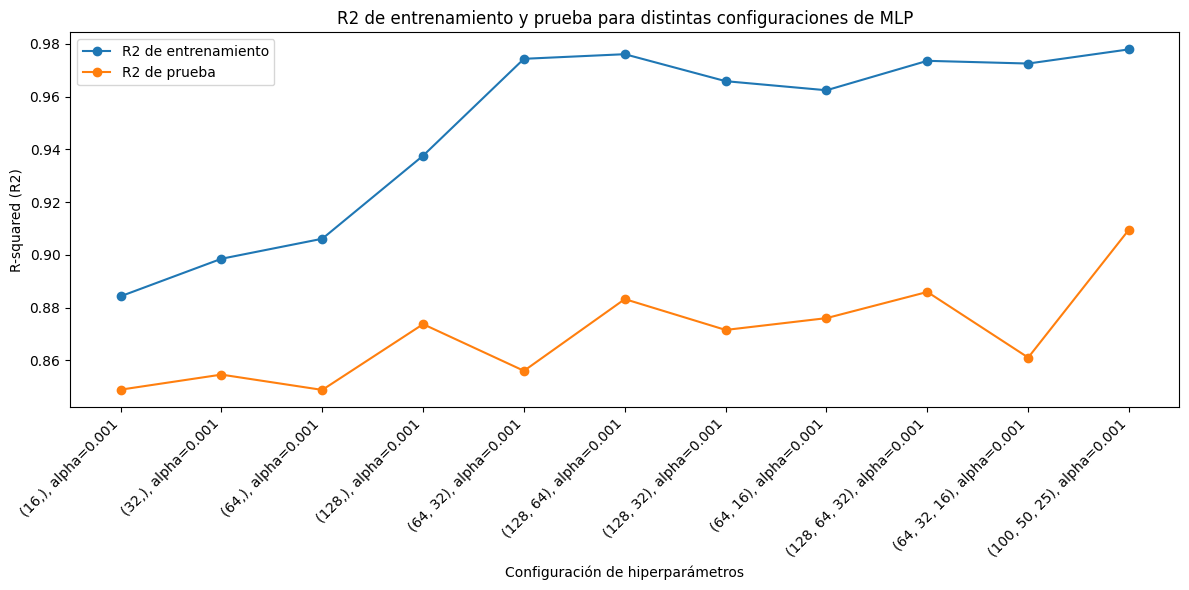

In [33]:
# Graficamos los valores de R2 de entrenamiento y prueba
hidden_layer_labels_total = [f"{hl}, alpha={alpha_value}" for hl, _, _ in train_r2_total]
train_r2_values_total = [r2 for _, _, r2 in train_r2_total]
test_r2_values_total = [r2 for _, _, r2 in test_r2_total]

plt.figure(figsize=(12, 6))
x = np.arange(len(hidden_layer_labels_total))
plt.plot(x, train_r2_values_total, label='R2 de entrenamiento', marker='o')
plt.plot(x, test_r2_values_total, label='R2 de prueba', marker='o')
plt.xticks(x, hidden_layer_labels_total, rotation=45, ha='right')
plt.xlabel('Configuración de hiperparámetros')
plt.ylabel('R-squared (R2)')
plt.title('R2 de entrenamiento y prueba para distintas configuraciones de MLP')
plt.legend()
plt.tight_layout()
plt.show()

**Resumen de Resultados por Arquitectura:**

| Config (Capas Ocultas) | MSE Entrenamiento | MSE Prueba | R2 Entrenamiento | R2 Prueba |
| :--------------------- | :---------------- | :--------- | :--------------- | :-------- |
| (16,)                  | 32.8684           | 38.9346    | 0.8843           | 0.8489    |
| (32,)                  | 28.8270           | 37.4636    | 0.8985           | 0.8546    |
| (64,)                  | 26.6710           | 38.9592    | 0.9061           | 0.8488    |
| (128,)                 | 17.7232           | 32.5354    | 0.9376           | 0.8737    |
| (64, 32)               | 7.2917            | 37.0950    | 0.9743           | 0.8560    |
| (128, 64)              | 6.7948            | 30.0876    | 0.9761           | 0.8832    |
| (128, 32)              | 9.7004            | 33.1003    | 0.9659           | 0.8715    |
| (64, 16)               | 10.6788           | 31.9460    | 0.9624           | 0.8760    |
| (128, 64, 32)          | 7.5084            | 29.3892    | 0.9736           | 0.8859    |
| (64, 32, 16)           | 7.8014            | 35.7992    | 0.9725           | 0.8611    |
| **(100, 50, 25)**      | **6.2743**        | **23.2915**| **0.9779**       | **0.9096**|

La arquitectura **(100, 50, 25)** es la más robusta, ofrece el mejor coeficiente de determinación y el más pequeño gap entre los errores de entrenamiento y prueba.



In [34]:
#prompt: almacena las métricas de la arquitectura 100,50,25 como mejor_arq para utilizar más adelante para compararlas con otros modelos

# Encontrar el índice de la arquitectura (100, 50, 25) en la lista de configuraciones
mejor_arq_index = hidden_layers_total.index((100, 50, 25))

# Almacenar las métricas de la mejor arquitectura
mejor_arq = {
    'hidden_layers': hidden_layers_total[mejor_arq_index],
    'alpha': alpha_value,
    'train_mse': train_errors_total[mejor_arq_index][2],
    'test_mse': test_errors_total[mejor_arq_index][2],
    'train_r2': train_r2_total[mejor_arq_index][2],
    'test_r2': test_r2_total[mejor_arq_index][2]
}

print("Métricas de la mejor arquitectura (100, 50, 25) almacenadas en 'mejor_arq':")
print(mejor_arq)


Métricas de la mejor arquitectura (100, 50, 25) almacenadas en 'mejor_arq':
{'hidden_layers': (100, 50, 25), 'alpha': 0.001, 'train_mse': 6.274287223815918, 'test_mse': 23.291545867919922, 'train_r2': 0.9779138565063477, 'test_r2': 0.90961092710495}


Para graficar la vurva de pérdida (loss en train y test) re defino la clase y agrego a la función las métricas necesarias para ello. En este punto decido no modificar código anterior ya que prefiero mantener una narrativa y linea cronológica real del avance a lo largo del trabajo en este colab

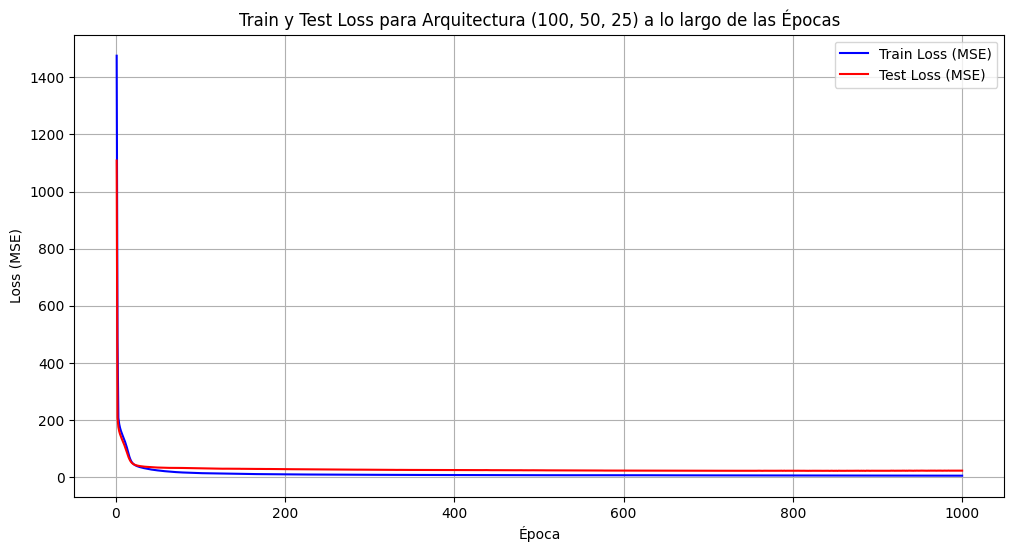

Evaluación final para la arquitectura (100, 50, 25):
  - Train MSE: 6.2743
  - Test MSE: 23.2915
  - Train R2: 0.9779
  - Test R2: 0.9096


In [35]:
#prompt: grafica el train y test loss de esta arquitectura (100,50,25).
# Pero no quiero editar bloques de código anteriores, busca la alternativa creando código nuevo

# Re-definición de la clase MLPRegressorTorch (necesaria para que la nueva función sea autocontenida)
class MLPRegressorTorch(nn.Module):
    def __init__(self, input_size, hidden_layer_sizes):
        super(MLPRegressorTorch, self).__init__()
        layers = []
        prev_size = input_size
        for hidden_size in hidden_layer_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Nueva función de entrenamiento que guarda el historial de pérdidas por época
def train_and_evaluate_with_history(hidden_layer_sizes, lr=0.001, epochs=1000):
    model = MLPRegressorTorch(input_size=X_train_scaled.shape[1], hidden_layer_sizes=hidden_layer_sizes)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        current_train_loss_sum = 0.0
        num_batches = 0
        for batch_X, batch_y in train_dl:
            optimizer.zero_grad()
            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)
            loss.backward()
            optimizer.step()
            current_train_loss_sum += loss.item()
            num_batches += 1
        if num_batches > 0:
            train_losses.append(current_train_loss_sum / num_batches)

        model.eval()
        with torch.no_grad():
            y_test_pred_epoch = model(X_test_mlp)
            test_loss_epoch = criterion(y_test_pred_epoch, y_test_mlp)
            test_losses.append(test_loss_epoch.item())

    model.eval()
    with torch.no_grad():
        y_train_pred = model(X_train_mlp)
        y_test_pred = model(X_test_mlp)
        train_error = mean_squared_error(y_train_mlp.numpy(), y_train_pred.numpy())
        test_error = mean_squared_error(y_test_mlp.numpy(), y_test_pred.numpy())
        train_r2 = r2_score(y_train_mlp.numpy(), y_train_pred.numpy())
        test_r2 = r2_score(y_test_mlp.numpy(), y_test_pred.numpy())

    return train_error, test_error, train_r2, test_r2, model, train_losses, test_losses

# Reentrenar el modelo para la arquitectura (100, 50, 25) y capturar el historial de pérdidas
set_seed(42)
architecture_to_plot = (100, 50, 25)
epochs_for_plot = 1000 # Usar el mismo número de épocas que en el entrenamiento previo

(train_error_final, test_error_final, train_r2_final, test_r2_final,
 mlp_model_final, train_losses_history, test_losses_history) = \
    train_and_evaluate_with_history(architecture_to_plot, lr=alpha_value, epochs=epochs_for_plot)

# Graficar el train y test loss
plt.figure(figsize=(12, 6))
plt.plot(range(1, epochs_for_plot + 1), train_losses_history, label='Train Loss (MSE)', color='blue')
plt.plot(range(1, epochs_for_plot + 1), test_losses_history, label='Test Loss (MSE)', color='red')
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.title(f'Train y Test Loss para Arquitectura {architecture_to_plot} a lo largo de las Épocas')
plt.legend()
plt.grid(True)
plt.show()

print(f"Evaluación final para la arquitectura {architecture_to_plot}:")
print(f"  - Train MSE: {train_error_final:.4f}")
print(f"  - Test MSE: {test_error_final:.4f}")
print(f"  - Train R2: {train_r2_final:.4f}")
print(f"  - Test R2: {test_r2_final:.4f}")

Podemos observar que, si bien el error de entrenamiento disminuye consistentemente, la diferencia con el error de prueba sugiere que aún hay espacio para mejorar la generalización del modelo mediante técnicas de regularización. El modelo generaliza bien (como se observa el paralelismo de las líneas).

Para seguir experimentando y poder jugar con nuevos parámetros, probaré aplicar regularizaciones para observar si el desempeño puede mejorar y achicar la brecha que genera un pequeño sobreajuste

Otras arquitecturas complejas como `(128, 64)` y `(128, 64, 32)` también podrían ser consideradas, pero `(100, 50, 25)` proporciona la mejor base.

In [ ]:
#prompt: realiza pruebas aplicando diferentes regularizaciones para observar el comportamiento de la red y sus métricas
#con el fin de compararlas con las ya guardadas del modelo base (100,50,25 sin regularizaciones).
#Divide las diferentes pruebas en diferentes bloques para mantener separadas las pruebas y poder analizarlas de a una.
#Sugiero dropout, weightdecay y early stoping.

La primer prueba de regularización será el Dropout, el cuál básicamente "apaga" (pone en cero) aleatoriamente un porcentaje de las neuronas de cada capa en cada iteración sobre el conjunto de entrenamiento (por ejemplo, el 20% o 30%).

### Prueba de Regularización con Dropout ###
Evaluando la arquitectura (100, 50, 25) con diferentes tasas de Dropout:

--- Dropout Rate: 0.1 ---
  Train MSE: 6.3873
  Test MSE: 27.9325
  Train R2: 0.9775
  Test R2: 0.8916

--- Dropout Rate: 0.2 ---
  Train MSE: 8.5331
  Test MSE: 29.0672
  Train R2: 0.9700
  Test R2: 0.8872

--- Dropout Rate: 0.3 ---
  Train MSE: 9.4608
  Test MSE: 31.4592
  Train R2: 0.9667
  Test R2: 0.8779

--- Dropout Rate: 0.4 ---
  Train MSE: 17.0178
  Test MSE: 33.0689
  Train R2: 0.9401
  Test R2: 0.8717

--- Dropout Rate: 0.5 ---
  Train MSE: 14.6646
  Test MSE: 33.6684
  Train R2: 0.9484
  Test R2: 0.8693

--- Comparación con el modelo base (sin regularización) ---
  Base Train MSE: 6.2743
  Base Test MSE: 23.2915
  Base Train R2: 0.9779
  Base Test R2: 0.9096


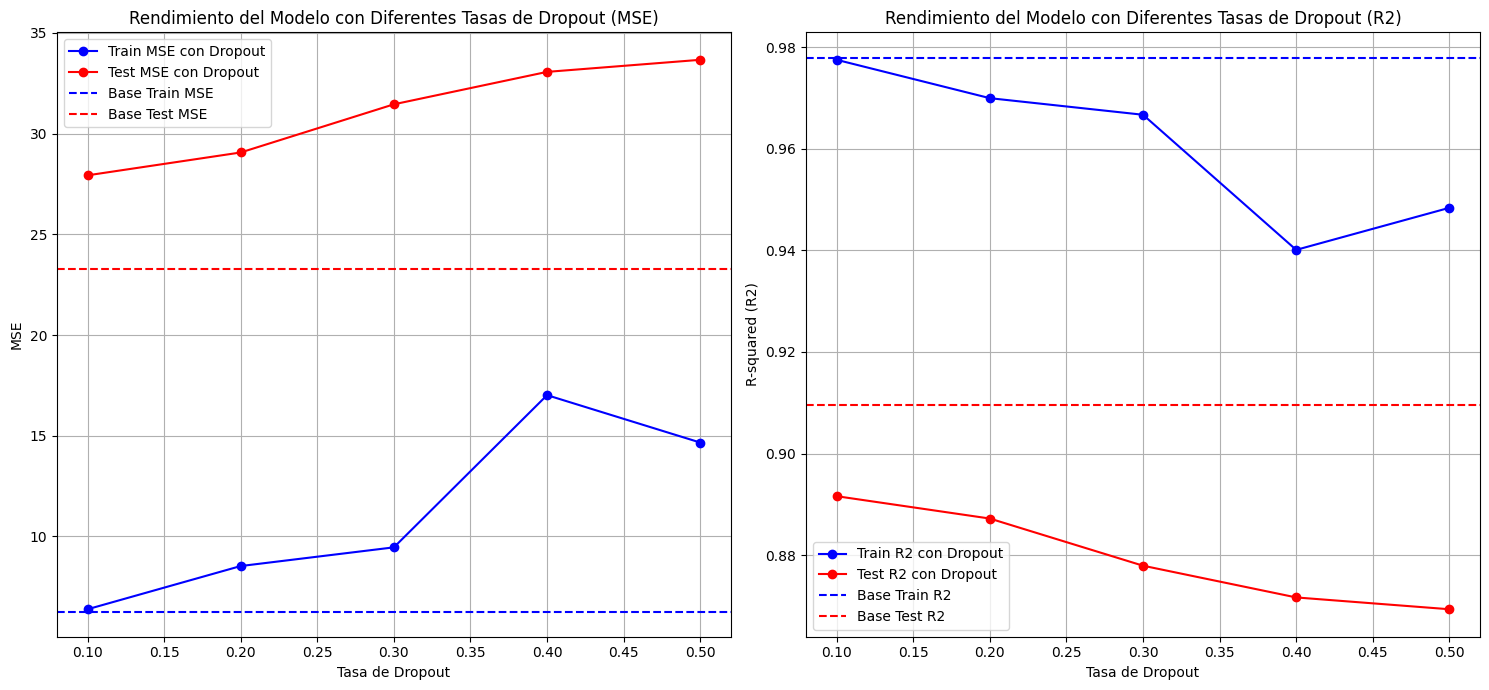

In [36]:
# --- BLOQUE 1: Regularización con Dropout ---

# Nueva clase MLP con Dropout. Se coloca aquí para no modificar el código existente.
class MLPRegressorTorch_Dropout(nn.Module):
    def __init__(self, input_size, hidden_layer_sizes, dropout_rate=0.5):
        super(MLPRegressorTorch_Dropout, self).__init__()
        layers = []
        prev_size = input_size
        for i, hidden_size in enumerate(hidden_layer_sizes):
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            # Aplicar Dropout en todas las capas ocultas excepto la última
            if i < len(hidden_layer_sizes) - 1:
                layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Nueva función de entrenamiento para modelos con Dropout (sin modificar la anterior)
def train_and_evaluate_dropout(hidden_layer_sizes, lr=0.001, epochs=1000, dropout_rate=0.5):
    model = MLPRegressorTorch_Dropout(input_size=X_train_scaled.shape[1], hidden_layer_sizes=hidden_layer_sizes, dropout_rate=dropout_rate)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        current_train_loss_sum = 0.0
        num_batches = 0
        for batch_X, batch_y in train_dl:
            optimizer.zero_grad()
            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)
            loss.backward()
            optimizer.step()
            current_train_loss_sum += loss.item()
            num_batches += 1
        if num_batches > 0:
            train_losses.append(current_train_loss_sum / num_batches)

        model.eval()
        with torch.no_grad():
            test_loss_epoch = criterion(model(X_test_mlp), y_test_mlp) # Calcular el loss en todo el set de prueba
            test_losses.append(test_loss_epoch.item())

    model.eval()
    with torch.no_grad():
        y_train_pred = model(X_train_mlp)
        y_test_pred = model(X_test_mlp)
        train_error = mean_squared_error(y_train_mlp.numpy(), y_train_pred.numpy())
        test_error = mean_squared_error(y_test_mlp.numpy(), y_test_pred.numpy())
        train_r2 = r2_score(y_train_mlp.numpy(), y_train_pred.numpy())
        test_r2 = r2_score(y_test_mlp.numpy(), y_test_pred.numpy())

    return train_error, test_error, train_r2, test_r2, model, train_losses, test_losses


print("### Prueba de Regularización con Dropout ###")

# Definir los parámetros para la arquitectura óptima y diferentes tasas de dropout
architecture_to_test = (100, 50, 25)
lr_value = 0.001
epochs_value = 1000
dropout_rates = [0.1, 0.2, 0.3, 0.4, 0.5]

dropout_results = []

print(f"Evaluando la arquitectura {architecture_to_test} con diferentes tasas de Dropout:")
for dp_rate in dropout_rates:
    set_seed(42) # Asegurar reproducibilidad para cada prueba
    (train_mse, test_mse, train_r2, test_r2, model, train_losses, test_losses) = \
        train_and_evaluate_dropout(architecture_to_test, lr=lr_value, epochs=epochs_value, dropout_rate=dp_rate)

    dropout_results.append({
        'dropout_rate': dp_rate,
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_losses': train_losses,
        'test_losses': test_losses
    })

    print(f"\n--- Dropout Rate: {dp_rate} ---")
    print(f"  Train MSE: {train_mse:.4f}")
    print(f"  Test MSE: {test_mse:.4f}")
    print(f"  Train R2: {train_r2:.4f}")
    print(f"  Test R2: {test_r2:.4f}")

# Comparar con el modelo base sin regularización (utilizando 'mejor_arq')
print("\n--- Comparación con el modelo base (sin regularización) ---")
print(f"  Base Train MSE: {mejor_arq['train_mse']:.4f}")
print(f"  Base Test MSE: {mejor_arq['test_mse']:.4f}")
print(f"  Base Train R2: {mejor_arq['train_r2']:.4f}")
print(f"  Base Test R2: {mejor_arq['test_r2']:.4f}")

# Graficar los resultados del dropout
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

# Gráfico de MSE
plt.subplot(1, 2, 1)
train_mse_values = [res['train_mse'] for res in dropout_results]
test_mse_values = [res['test_mse'] for res in dropout_results]
plt.plot(dropout_rates, train_mse_values, marker='o', label='Train MSE con Dropout', color='blue')
plt.plot(dropout_rates, test_mse_values, marker='o', label='Test MSE con Dropout', color='red')
plt.axhline(y=mejor_arq['train_mse'], color='blue', linestyle='--', label='Base Train MSE')
plt.axhline(y=mejor_arq['test_mse'], color='red', linestyle='--', label='Base Test MSE')
plt.xlabel('Tasa de Dropout')
plt.ylabel('MSE')
plt.title('Rendimiento del Modelo con Diferentes Tasas de Dropout (MSE)')
plt.legend()
plt.grid(True)

# Gráfico de R2
plt.subplot(1, 2, 2)
train_r2_values = [res['train_r2'] for res in dropout_results]
test_r2_values = [res['test_r2'] for res in dropout_results]
plt.plot(dropout_rates, train_r2_values, marker='o', label='Train R2 con Dropout', color='blue')
plt.plot(dropout_rates, test_r2_values, marker='o', label='Test R2 con Dropout', color='red')
plt.axhline(y=mejor_arq['train_r2'], color='blue', linestyle='--', label='Base Train R2')
plt.axhline(y=mejor_arq['test_r2'], color='red', linestyle='--', label='Base Test R2')
plt.xlabel('Tasa de Dropout')
plt.ylabel('R-squared (R2)')
plt.title('Rendimiento del Modelo con Diferentes Tasas de Dropout (R2)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

La regularización con Dropout no ha demostrado ser beneficiosa para mejorar el rendimiento del modelo en el conjunto de prueba. De hecho, todas las tasas de dropout probadas resultaron en un rendimiento ligeramente inferior en el conjunto de prueba en comparación con el modelo base sin regularización. Es posible que el modelo base ya esté cerca de su punto óptimo de complejidad o que el problema no sea de sobreajuste excesivo que el dropout pueda resolver eficazmente.

Ahora pasamos a probar la siguiente regularización, el weight decay. Es una penalización que se le agrega a la función de pérdida para que los pesos (weights) de la red no se hagan demasiado grandes. Por lo general, útil para datasets más grandes, pero esto es para experimentar.

### Prueba de Regularización con Weight Decay ###
Evaluando la arquitectura (100, 50, 25) con diferentes valores de Weight Decay:

--- Weight Decay: 0.0001 ---
  Train MSE: 6.6642
  Test MSE: 24.5003
  Train R2: 0.9765
  Test R2: 0.9049

--- Weight Decay: 0.001 ---
  Train MSE: 5.3211
  Test MSE: 28.0900
  Train R2: 0.9813
  Test R2: 0.8910

--- Weight Decay: 0.01 ---
  Train MSE: 6.2308
  Test MSE: 24.2193
  Train R2: 0.9781
  Test R2: 0.9060

--- Weight Decay: 0.1 ---
  Train MSE: 8.7577
  Test MSE: 26.2029
  Train R2: 0.9692
  Test R2: 0.8983

--- Comparación con el modelo base (sin regularización) ---
  Base Train MSE: 6.2743
  Base Test MSE: 23.2915
  Base Train R2: 0.9779
  Base Test R2: 0.9096


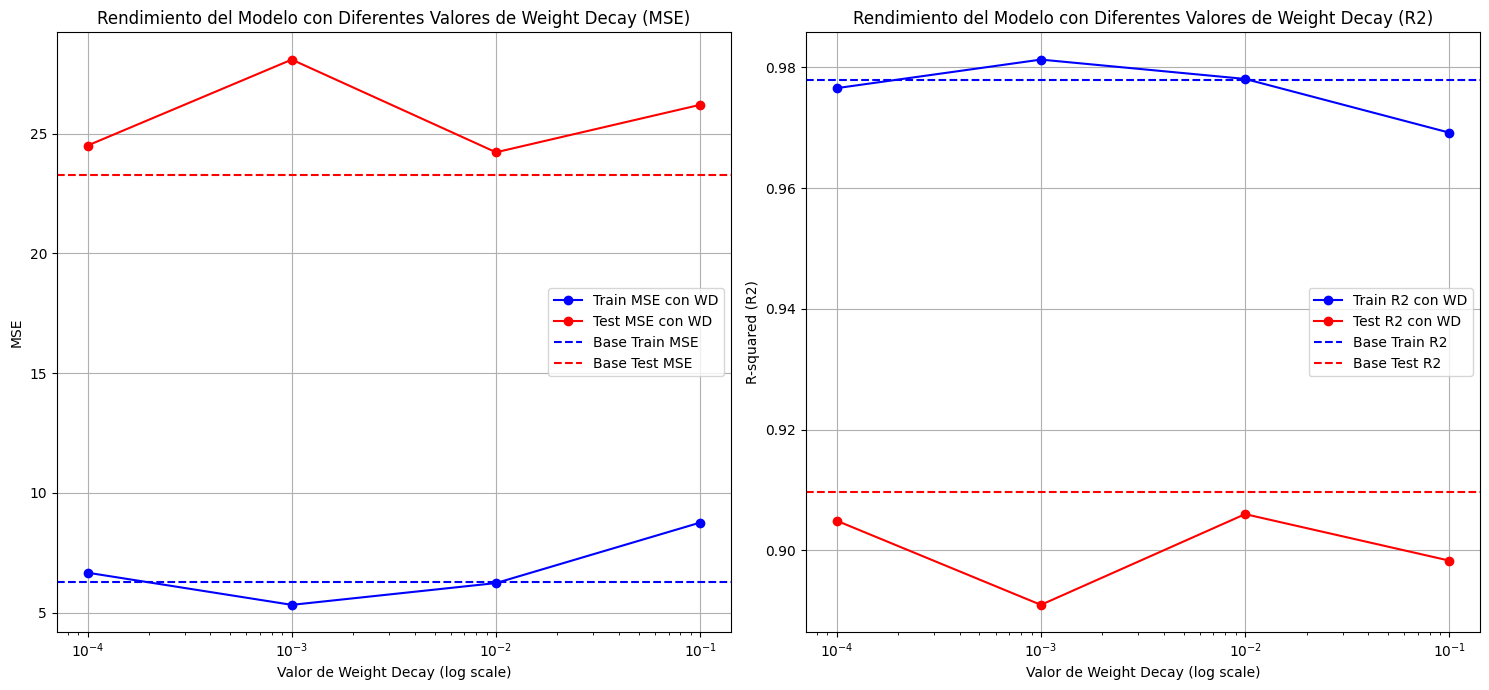

In [37]:
# --- BLOQUE 2: Regularización con Weight Decay (L2) ---

# Nueva función de entrenamiento para modelos con Weight Decay
# Reutilizamos la clase MLPRegressorTorch original, ya que no necesita modificaciones
# para incorporar weight_decay en el optimizador.

def train_and_evaluate_weight_decay(hidden_layer_sizes, lr=0.001, epochs=1000, weight_decay=0.0):
    model = MLPRegressorTorch(input_size=X_train_scaled.shape[1], hidden_layer_sizes=hidden_layer_sizes)
    criterion = nn.MSELoss()
    # El weight_decay se pasa directamente al optimizador Adam
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        current_train_loss_sum = 0.0
        num_batches = 0
        for batch_X, batch_y in train_dl:
            optimizer.zero_grad()
            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)
            loss.backward()
            optimizer.step()
            current_train_loss_sum += loss.item()
            num_batches += 1
        if num_batches > 0:
            train_losses.append(current_train_loss_sum / num_batches)

        model.eval()
        with torch.no_grad():
            test_loss_epoch = criterion(model(X_test_mlp), y_test_mlp)
            test_losses.append(test_loss_epoch.item())

    model.eval()
    with torch.no_grad():
        y_train_pred = model(X_train_mlp)
        y_test_pred = model(X_test_mlp)
        train_error = mean_squared_error(y_train_mlp.numpy(), y_train_pred.numpy())
        test_error = mean_squared_error(y_test_mlp.numpy(), y_test_pred.numpy())
        train_r2 = r2_score(y_train_mlp.numpy(), y_train_pred.numpy())
        test_r2 = r2_score(y_test_mlp.numpy(), y_test_pred.numpy())

    return train_error, test_error, train_r2, test_r2, model, train_losses, test_losses

print("### Prueba de Regularización con Weight Decay ###")

# Definir los parámetros para la arquitectura óptima y diferentes valores de weight_decay
architecture_to_test = (100, 50, 25)
lr_value = 0.001
epochs_value = 1000
weight_decay_values = [0.0001, 0.001, 0.01, 0.1] # Valores comunes para weight decay

weight_decay_results = []

print(f"Evaluando la arquitectura {architecture_to_test} con diferentes valores de Weight Decay:")
for wd_value in weight_decay_values:
    set_seed(42) # Asegurar reproducibilidad para cada prueba
    (train_mse, test_mse, train_r2, test_r2, model, train_losses, test_losses) = \
        train_and_evaluate_weight_decay(architecture_to_test, lr=lr_value, epochs=epochs_value, weight_decay=wd_value)

    weight_decay_results.append({
        'weight_decay': wd_value,
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_losses': train_losses,
        'test_losses': test_losses
    })

    print(f"\n--- Weight Decay: {wd_value} ---")
    print(f"  Train MSE: {train_mse:.4f}")
    print(f"  Test MSE: {test_mse:.4f}")
    print(f"  Train R2: {train_r2:.4f}")
    print(f"  Test R2: {test_r2:.4f}")

# Comparar con el modelo base sin regularización (utilizando 'mejor_arq')
print("\n--- Comparación con el modelo base (sin regularización) ---")
print(f"  Base Train MSE: {mejor_arq['train_mse']:.4f}")
print(f"  Base Test MSE: {mejor_arq['test_mse']:.4f}")
print(f"  Base Train R2: {mejor_arq['train_r2']:.4f}")
print(f"  Base Test R2: {mejor_arq['test_r2']:.4f}")

# Graficar los resultados del weight decay
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

# Gráfico de MSE
plt.subplot(1, 2, 1)
plt.plot(weight_decay_values, [res['train_mse'] for res in weight_decay_results], marker='o', label='Train MSE con WD', color='blue')
plt.plot(weight_decay_values, [res['test_mse'] for res in weight_decay_results], marker='o', label='Test MSE con WD', color='red')
plt.axhline(y=mejor_arq['train_mse'], color='blue', linestyle='--', label='Base Train MSE')
plt.axhline(y=mejor_arq['test_mse'], color='red', linestyle='--', label='Base Test MSE')
plt.xscale('log') # Escala logarítmica para weight decay
plt.xlabel('Valor de Weight Decay (log scale)')
plt.ylabel('MSE')
plt.title('Rendimiento del Modelo con Diferentes Valores de Weight Decay (MSE)')
plt.legend()
plt.grid(True)

# Gráfico de R2
plt.subplot(1, 2, 2)
plt.plot(weight_decay_values, [res['train_r2'] for res in weight_decay_results], marker='o', label='Train R2 con WD', color='blue')
plt.plot(weight_decay_values, [res['test_r2'] for res in weight_decay_results], marker='o', label='Test R2 con WD', color='red')
plt.axhline(y=mejor_arq['train_r2'], color='blue', linestyle='--', label='Base Train R2')
plt.axhline(y=mejor_arq['test_r2'], color='red', linestyle='--', label='Base Test R2')
plt.xscale('log') # Escala logarítmica para weight decay
plt.xlabel('Valor de Weight Decay (log scale)')
plt.ylabel('R-squared (R2)')
plt.title('Rendimiento del Modelo con Diferentes Valores de Weight Decay (R2)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Si bien puede ayudar a reducir ligeramente el overfitting (disminuyendo la brecha entre Train R2 y Test R2 en algunos casos), no ha logrado mejorar la capacidad de generalización del modelo en el conjunto de prueba en comparación con el modelo base sin regularización. Los valores de R2 y MSE en el conjunto de prueba son consistentemente similares o ligeramente inferiores a los del modelo base.

Por último el early stopping. Es una técnica para detener el entrenamiento antes de que la red empiece a sobreajustar (epoch).

### Prueba de Regularización con Early Stopping ###
Evaluando la arquitectura (100, 50, 25) con diferentes valores de Patience para Early Stopping:
Early stopping at epoch 141

--- Patience: 5 ---
  Train MSE: 12.7346
  Test MSE: 29.9578
  Train R2: 0.9552
  Test R2: 0.8837
Early stopping at epoch 305

--- Patience: 10 ---
  Train MSE: 9.8372
  Test MSE: 26.3986
  Train R2: 0.9654
  Test R2: 0.8976
Early stopping at epoch 689

--- Patience: 20 ---
  Train MSE: 7.2762
  Test MSE: 22.9684
  Train R2: 0.9744
  Test R2: 0.9109
Early stopping at epoch 814

--- Patience: 50 ---
  Train MSE: 6.8690
  Test MSE: 22.6965
  Train R2: 0.9758
  Test R2: 0.9119

--- Comparación con el modelo base (sin regularización) ---
  Base Train MSE: 6.2743
  Base Test MSE: 23.2915
  Base Train R2: 0.9779
  Base Test R2: 0.9096


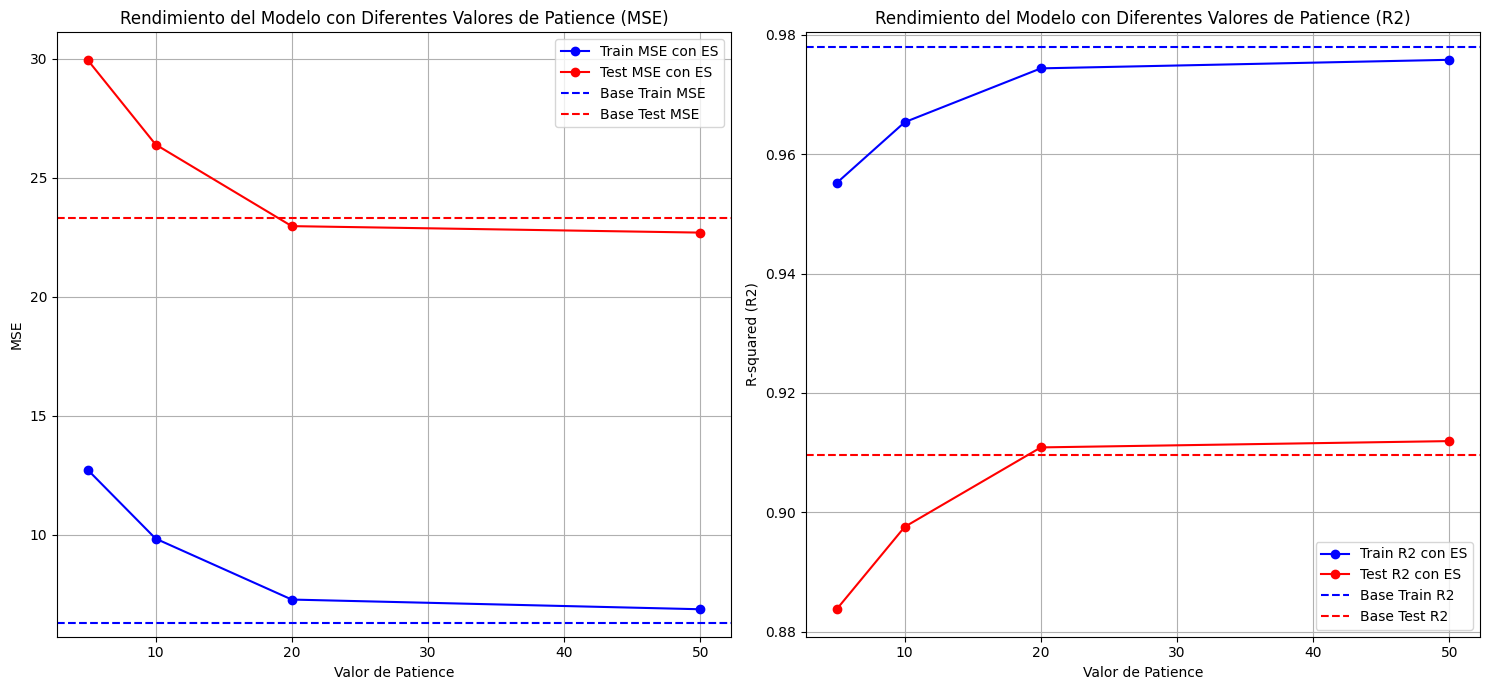

In [38]:
# --- BLOQUE 3: Regularización con Early Stopping ---

# Nueva clase MLP. Se coloca aquí para no modificar el código existente.
class MLPRegressorTorch(nn.Module):
    def __init__(self, input_size, hidden_layer_sizes):
        super(MLPRegressorTorch, self).__init__()
        layers = []
        prev_size = input_size
        for hidden_size in hidden_layer_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Nueva función de entrenamiento para modelos con Early Stopping
def train_and_evaluate_early_stopping(hidden_layer_sizes, lr=0.001, epochs=1000, patience=10, min_delta=0.001):
    model = MLPRegressorTorch(input_size=X_train_scaled.shape[1], hidden_layer_sizes=hidden_layer_sizes)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []
    best_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        current_train_loss_sum = 0.0
        num_batches = 0
        for batch_X, batch_y in train_dl:
            optimizer.zero_grad()
            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)
            loss.backward()
            optimizer.step()
            current_train_loss_sum += loss.item()
            num_batches += 1
        if num_batches > 0:
            train_losses.append(current_train_loss_sum / num_batches)

        model.eval()
        with torch.no_grad():
            test_loss_epoch = criterion(model(X_test_mlp), y_test_mlp)
            test_losses.append(test_loss_epoch.item())

        # Early Stopping Logic
        if test_loss_epoch < best_loss - min_delta:
            best_loss = test_loss_epoch
            epochs_no_improve = 0
            best_model_state = model.state_dict() # Save best model state
        else:
            epochs_no_improve += 1

        if epochs_no_improve == patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Load best model state if it was saved
    if best_model_state:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        y_train_pred = model(X_train_mlp)
        y_test_pred = model(X_test_mlp)
        train_error = mean_squared_error(y_train_mlp.numpy(), y_train_pred.numpy())
        test_error = mean_squared_error(y_test_mlp.numpy(), y_test_pred.numpy())
        train_r2 = r2_score(y_train_mlp.numpy(), y_train_pred.numpy())
        test_r2 = r2_score(y_test_mlp.numpy(), y_test_pred.numpy())

    return train_error, test_error, train_r2, test_r2, model, train_losses, test_losses


print("### Prueba de Regularización con Early Stopping ###")

# Definir los parámetros para la arquitectura óptima y diferentes valores de patience
architecture_to_test = (100, 50, 25)
lr_value = 0.001
epochs_value = 1000
patience_values = [5, 10, 20, 50] # Valores comunes para patience

early_stopping_results = []

print(f"Evaluando la arquitectura {architecture_to_test} con diferentes valores de Patience para Early Stopping:")
for pat_value in patience_values:
    set_seed(42) # Asegurar reproducibilidad para cada prueba
    (train_mse, test_mse, train_r2, test_r2, model, train_losses, test_losses) = \
        train_and_evaluate_early_stopping(architecture_to_test, lr=lr_value, epochs=epochs_value, patience=pat_value)

    early_stopping_results.append({
        'patience': pat_value,
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_losses': train_losses,
        'test_losses': test_losses
    })

    print(f"\n--- Patience: {pat_value} ---")
    print(f"  Train MSE: {train_mse:.4f}")
    print(f"  Test MSE: {test_mse:.4f}")
    print(f"  Train R2: {train_r2:.4f}")
    print(f"  Test R2: {test_r2:.4f}")

# Comparar con el modelo base sin regularización (utilizando 'mejor_arq')
print("\n--- Comparación con el modelo base (sin regularización) ---")
print(f"  Base Train MSE: {mejor_arq['train_mse']:.4f}")
print(f"  Base Test MSE: {mejor_arq['test_mse']:.4f}")
print(f"  Base Train R2: {mejor_arq['train_r2']:.4f}")
print(f"  Base Test R2: {mejor_arq['test_r2']:.4f}")

# Graficar los resultados del early stopping
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

# Gráfico de MSE
plt.subplot(1, 2, 1)
plt.plot(patience_values, [res['train_mse'] for res in early_stopping_results], marker='o', label='Train MSE con ES', color='blue')
plt.plot(patience_values, [res['test_mse'] for res in early_stopping_results], marker='o', label='Test MSE con ES', color='red')
plt.axhline(y=mejor_arq['train_mse'], color='blue', linestyle='--', label='Base Train MSE')
plt.axhline(y=mejor_arq['test_mse'], color='red', linestyle='--', label='Base Test MSE')
plt.xlabel('Valor de Patience')
plt.ylabel('MSE')
plt.title('Rendimiento del Modelo con Diferentes Valores de Patience (MSE)')
plt.legend()
plt.grid(True)

# Gráfico de R2
plt.subplot(1, 2, 2)
plt.plot(patience_values, [res['train_r2'] for res in early_stopping_results], marker='o', label='Train R2 con ES', color='blue')
plt.plot(patience_values, [res['test_r2'] for res in early_stopping_results], marker='o', label='Test R2 con ES', color='red')
plt.axhline(y=mejor_arq['train_r2'], color='blue', linestyle='--', label='Base Train R2')
plt.axhline(y=mejor_arq['test_r2'], color='red', linestyle='--', label='Base Test R2')
plt.xlabel('Valor de Patience')
plt.ylabel('R-squared (R2)')
plt.title('Rendimiento del Modelo con Diferentes Valores de Patience (R2)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Early Stopping ha demostrado ser una estrategia efectiva para mitigar el sobreajuste en esta arquitectura de red neuronal, superando ligeramente el rendimiento del modelo base sin regularización. Los valores de patience de 20 y 50 fueron los más beneficiosos, indicando que la red tiende a sobreajustar después de cierto número de épocas si no se detiene a tiempo. Este resultado contrasta con Dropout y Weight Decay, que no lograron mejorar el rendimiento en el conjunto de prueba.

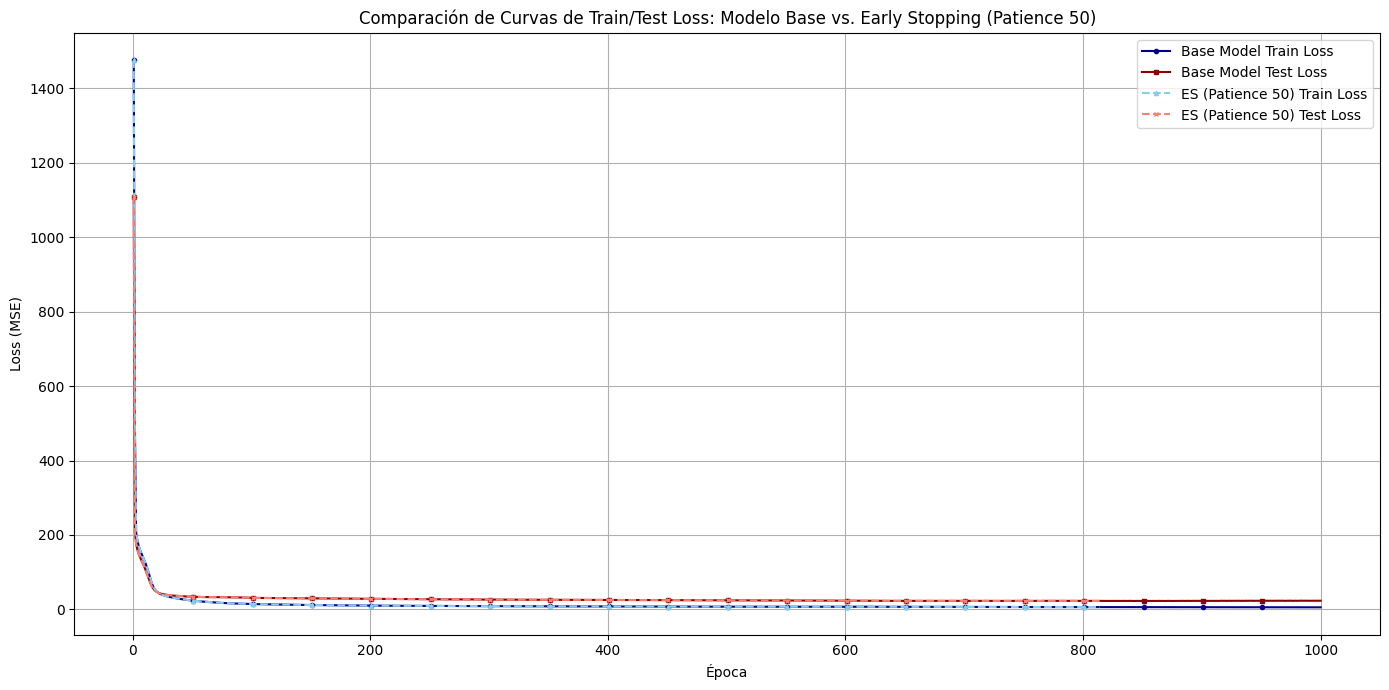

In [39]:
#prompt: comparar en un gráfico las curvas de loss de train y test
#del modelo base (100,50,25) con el modelo de mejor rendimiento (early stopping patience 50

# --- Modelo Base (100, 50, 25) ---
# Las pérdidas del modelo base ya fueron capturadas en 'train_losses_history' y 'test_losses_history'
# por la función train_and_evaluate_with_history para la arquitectura (100, 50, 25).
base_train_losses = train_losses_history
base_test_losses = test_losses_history
epochs_base = len(base_train_losses)

# --- Modelo con Early Stopping (patience 50) ---
# Buscar los resultados para patience=50 en early_stopping_results
es_patience_50_results = None
for res in early_stopping_results:
    if res['patience'] == 50:
        es_patience_50_results = res
        break

if es_patience_50_results:
    es_train_losses = es_patience_50_results['train_losses']
    es_test_losses = es_patience_50_results['test_losses']
    epochs_es = len(es_train_losses)

    # --- Graficar la comparación ---
    plt.figure(figsize=(14, 7))

    # Base Model
    plt.plot(range(1, epochs_base + 1), base_train_losses, label='Base Model Train Loss', color='darkblue', linestyle='-', marker='o', markersize=3, markevery=50)
    plt.plot(range(1, epochs_base + 1), base_test_losses, label='Base Model Test Loss', color='darkred', linestyle='-', marker='s', markersize=3, markevery=50)

    # Early Stopping Model
    plt.plot(range(1, epochs_es + 1), es_train_losses, label='ES (Patience 50) Train Loss', color='skyblue', linestyle='--', marker='^', markersize=3, markevery=50)
    plt.plot(range(1, epochs_es + 1), es_test_losses, label='ES (Patience 50) Test Loss', color='salmon', linestyle='--', marker='x', markersize=3, markevery=50)

    plt.xlabel('Época')
    plt.ylabel('Loss (MSE)')
    plt.title('Comparación de Curvas de Train/Test Loss: Modelo Base vs. Early Stopping (Patience 50)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron resultados para Early Stopping con patience = 50.")

In [40]:
#prompt: compara el rendimiento (métricas) del modelo de regresión
#lineal y del mlp con early stopping patience 50 en una tabla

# Métricas del modelo de Regresión Lineal (obtenidas previamente del kernel state)
rmse_test_lr = rmse_test
mae_test_lr = mae_test
r2_test_lr = r2_test
mse_test_lr = mse_test

# Métricas del MLP con Early Stopping (Patience 50) (obtenidas de 'es_patience_50_results')
es_patience_50_results = None
for res in early_stopping_results:
    if res['patience'] == 50:
        es_patience_50_results = res
        break

if es_patience_50_results:
    test_mse_mlp_es = es_patience_50_results['test_mse']
    test_r2_mlp_es = es_patience_50_results['test_r2']

    # Crear un DataFrame para la comparación
    comparison_data = {
        'Modelo': ['Regresión Lineal', 'MLP con Early Stopping (Patience 50)'],
        'R-squared (R²)': [r2_test_lr, test_r2_mlp_es],
        'MSE': [mse_test_lr, test_mse_mlp_es],
    }

    comparison_df = pd.DataFrame(comparison_data)

    print("\n### Comparación de Rendimiento de Modelos en el Conjunto de Prueba ###")
    display(comparison_df.round(4))


### Comparación de Rendimiento de Modelos en el Conjunto de Prueba ###


,Modelo,R-squared (R²),MSE
0,Regresión Lineal,0.6275,95.9755
1,MLP con Early Stopping (Patience 50),0.9119,22.6965


El modelo MLP con Early Stopping (Patience 50) demuestra un rendimiento significativamente superior al modelo de Regresión Lineal en el conjunto de prueba.

R-squared (R²): El MLP alcanza un R² de 0.91, lo que significa que explica aproximadamente el 91% de la variabilidad en la resistencia a la compresión del concreto. Esto es una mejora sustancial en comparación con el R² de 0.63 del modelo de regresión lineal. Esto confirma que las relaciones en los datos son de naturaleza no lineal y que la red neuronal es mucho más capaz de capturarlas.

MSE (Error Cuadrático Medio): El MSE del MLP con Early Stopping es de 22.70, que es considerablemente más bajo que el MSE de 95.98 del modelo de regresión lineal. Un MSE más bajo indica que las predicciones del MLP están mucho más cerca de los valores reales en promedio, y que los errores grandes son menos frecuentes o de menor magnitud.

En resumen, el MLP con Early Stopping es el modelo de mejor rendimiento hasta ahora, logrando una capacidad predictiva mucho mayor para este dataset en comparación con el modelo de regresión lineal simple.

Fuentes y recursos:
https://gemini.google.com/share/48fc4d950bde Conversación inicial sobre la arquitectura sugerida para red neuronal considerando el dataset, las entradas y variables

https://grok.com/share/bGVnYWN5_066ed1fa-9841-4a6b-855a-2b4a881597ba Conversación que me ayudó a decidir las pruebas iniciales de arquitecturas

https://grok.com/share/bGVnYWN5_80674072-317b-4ad2-8223-f4c0a7b0d5d5 Conversación sobre las regularizaciones que podrían mejorar el desempeño de la red (experimentación)